# OncoBridge — Architecture & Training Notebook v4
## ChemBERTa Drug Encoder · Cross-Attention Fusion · Three-Split Evaluation

### Architecture:
```
mRNA + CNV + Mutation + Methylation
              ↓
 OncoBridgeMMCAT_v7 backbone (FROZEN)
              ↓
   1920-dim patient embedding (K, V)
                                  Drug SMILES
                                      ↓
                          ChemBERTa-77M-MLM (partial freeze)
                                      ↓
                              [CLS] token → 384-dim drug embedding (Q)
              ↓                        ↓
   Cross-Attention: Drug(Q) × Patient(K,V)
              ↓
      Regression MLP → LN(IC50)
```

### Key design decisions:
| Feature | Choice | Rationale |
|---------|--------|-----------|
| Drug encoder | ChemBERTa [CLS] | Full chemical language; enables drug cold-start |
| Fusion | Cross-Attention (not concat) | Drug queries patient embeddings; richer interaction |
| Backbone | FROZEN | Preserve TCGA pre-training; only 2x T4 VRAM |
| ChemBERTa | First 6 layers frozen | Save VRAM; keep last layers trainable |
| DataParallel | 2x T4 | Split batch across both GPUs |
| AMP + GradAccum | Yes | Fit large model in 15GB VRAM per GPU |

### Split Modes:
| Mode | Description | Use Case |
|------|-------------|----------|
| `warm` | Random 80/10/10 IC50-pair split | Standard benchmark |
| `cell_cold` | 20% cell lines held out | Generalisation to new cancer lines |
| `drug_cold` | 15% drugs held out | Generalisation to novel compounds |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS & IMPORTS
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('transformers', 'accelerate')
print('✓ transformers  ✓ accelerate installed.')

import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from transformers import AutoTokenizer, AutoModel

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'\nDevice: {DEVICE} | GPUs available: {N_GPUS}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f} GB VRAM')
print()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

✓ transformers  ✓ accelerate installed.

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4 | 15.6 GB VRAM
  GPU 1: Tesla T4 | 15.6 GB VRAM



In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — CONFIG
#
#  ★ KEY KNOB — set SPLIT_MODE to choose which split is used for
#    training, validation, AND test evaluation.
#
#    'warm'       → random IC50-pair split     (default, matches most papers)
#    'cell_cold'  → cell lines held-out test   (harder; tests generalisation)
#    'drug_cold'  → drugs held-out test        (hardest; novel compound setting)
# ═══════════════════════════════════════════════════════════════════════

# ── ★ CHOOSE YOUR SPLIT MODE HERE ────────────────────────────────────
SPLIT_MODE = 'cell_cold'   # Options: 'warm' | 'cell_cold' | 'drug_cold'
assert SPLIT_MODE in ('warm', 'cell_cold', 'drug_cold'), \
    f'Unknown SPLIT_MODE: {SPLIT_MODE!r}. Must be warm | cell_cold | drug_cold'

DATA_BASE  = '/kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2'
CKPT_PATH  = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR    = '/kaggle/working/'

PATH_MRNA       = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV        = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT        = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH       = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_SMILES     = f'{DATA_BASE}/drug_smiles.json'
PATH_DRUG_NAMES = f'{DATA_BASE}/valid_drug_names.csv'
PATH_DRUG2IDX   = f'{DATA_BASE}/drug2idx.json'

# All three splits defined — SPLIT_MODE selects which one is active.
SPLIT_PATHS = {
    'warm': {
        'train': f'{DATA_BASE}/split_warm_tr.parquet',
        'val':   f'{DATA_BASE}/split_warm_vl.parquet',
        'test':  f'{DATA_BASE}/split_warm_te.parquet',
    },
    'cell_cold': {
        'train': f'{DATA_BASE}/split_cc_tr.parquet',
        'val':   f'{DATA_BASE}/split_cc_vl.parquet',
        'test':  f'{DATA_BASE}/split_cc_te.parquet',
    },
    'drug_cold': {
        'train': f'{DATA_BASE}/split_dc_tr.parquet',
        'val':   f'{DATA_BASE}/split_dc_vl.parquet',
        'test':  f'{DATA_BASE}/split_dc_te.parquet',
    },
}
# No separate EVAL_TEST_PATHS — evaluation always uses SPLIT_PATHS[SPLIT_MODE]['test'].

CONFIG = {
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,
    'chemberta_model':         'DeepChem/ChemBERTa-77M-MLM',
    'chemberta_dim':           384,
    'chemberta_max_len':       512,
    'chemberta_freeze_layers': 6,
    'fusion_heads':    8,
    'fusion_dropout':  0.20,
    'batch_size':    32,
    'grad_accum':    4,
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.10,
    'stage1_epochs':   25,
    'stage1_lr':       5e-4,
    'stage1_wd':       1e-4,
    'stage1_patience': 7,
    'stage2_epochs':    30,
    'stage2_lr_head':   1e-4,
    'stage2_lr_cross':  5e-5,
    'stage2_lr_cbert':  2e-5,
    'stage2_wd':        1e-4,
    'stage2_patience':  10,
    'checkpoint_ft': f'{OUT_DIR}oncobridge_chemberta_v4_best.pt',
    'split_mode': SPLIT_MODE,
}

eff_batch = CONFIG['batch_size'] * max(N_GPUS, 1) * CONFIG['grad_accum']
print(f'\n{"="*60}')
print(f'  ★ SPLIT MODE : {SPLIT_MODE.upper()}')
print(f'    Train path : {SPLIT_PATHS[SPLIT_MODE]["train"]}')
print(f'    Val   path : {SPLIT_PATHS[SPLIT_MODE]["val"]}')
print(f'    Test  path : {SPLIT_PATHS[SPLIT_MODE]["test"]}')
print(f'  Effective batch size: {eff_batch}')
print(f'  ChemBERTa:           {CONFIG["chemberta_model"]}')
print(f'  Frozen layers:       first {CONFIG["chemberta_freeze_layers"]} transformer blocks')
print(f'{"="*60}')



  ★ SPLIT MODE : CELL_COLD
    Train path : /kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2/split_cc_tr.parquet
    Val   path : /kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2/split_cc_vl.parquet
    Test  path : /kaggle/input/datasets/proutkarshtiwari/smiles-correct-data-gdsc2/split_cc_te.parquet
  Effective batch size: 256
  ChemBERTa:           DeepChem/ChemBERTa-77M-MLM
  Frozen layers:       first 6 transformer blocks


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — LOAD PROCESSED DATA & SPLITS
#  Loads train/val/test for the active SPLIT_MODE only.
#  ic50_test is the single evaluation test set throughout this notebook.
# ═══════════════════════════════════════════════════════════════════════
section('3. LOAD PROCESSED DATA')

t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
print(f'Loaded omics in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')

with open(PATH_SMILES)   as f: smiles_map = json.load(f)
with open(PATH_DRUG2IDX) as f: drug2idx   = json.load(f)
DRUG_NAMES = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
id_to_drug = {int(i): d for d, i in drug2idx.items()}
n_drugs    = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | SMILES available: {sum(1 for v in smiles_map.values() if v)}')

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)

total_mb = (mrna_arr.nbytes + cnv_arr.nbytes + mut_arr.nbytes + meth_arr.nbytes) / 1e6
print(f'Omics RAM: {total_mb:.0f} MB (pre-stacked)')

def load_and_map_split(path):
    df = pd.read_parquet(path)
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug2idx)
    before = len(df)
    df = df.dropna(subset=['cl_idx', 'drug_idx'])
    if len(df) < before:
        print(f'    [warn] {before - len(df)} rows dropped (unmatched CL/drug) in {path.split("/")[-1]}')
    df['cl_idx']   = df['cl_idx'].astype(int)
    df['drug_idx'] = df['drug_idx'].astype(int)
    return df

print(f'\nLoading SPLIT_MODE = "{SPLIT_MODE}" train/val/test splits...')
ic50_train = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['train'])
ic50_val   = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['val'])
ic50_test  = load_and_map_split(SPLIT_PATHS[SPLIT_MODE]['test'])

print(f'  [{SPLIT_MODE}] Train: {len(ic50_train):>7,} pairs')
print(f'  [{SPLIT_MODE}] Val:   {len(ic50_val):>7,} pairs')
print(f'  [{SPLIT_MODE}] Test:  {len(ic50_test):>7,} pairs  ← evaluation set')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()
print('\nOriginal parquet DFs freed from memory.')



══════════════════════════════════════════════════════════════════════
  3. LOAD PROCESSED DATA
══════════════════════════════════════════════════════════════════════
Loaded omics in 1.5s
mRNA (388, 8011) | CNV (388, 3500) | Mut (388, 2500) | Meth (388, 6000)
Drugs: 74 | SMILES available: 74
Omics RAM: 31 MB (pre-stacked)

Loading SPLIT_MODE = "cell_cold" train/val/test splits...
  [cell_cold] Train:   6,993 pairs
  [cell_cold] Val:       833 pairs
  [cell_cold] Test:    2,141 pairs  ← evaluation set

Original parquet DFs freed from memory.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — DATASET & DATALOADERS
# ═══════════════════════════════════════════════════════════════════════
section('4. DATASET & DATALOADERS')

print(f'Loading ChemBERTa tokenizer: {CONFIG["chemberta_model"]}')
tokenizer = AutoTokenizer.from_pretrained(CONFIG['chemberta_model'])
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')


class DrugResponseDataset(Dataset):
    def __init__(self, df, mrna_arr, cnv_arr, mut_arr, meth_arr,
                 smiles_map, tokenizer, max_len=512):
        self.cl_idx     = df['cl_idx'].values.astype(np.int32)
        self.drug_idx   = df['drug_idx'].values.astype(np.int64)
        self.ic50       = df['ic50_value'].values.astype(np.float32)
        self.drug_names = df['DRUG_NAME'].values
        self.mrna_arr   = mrna_arr
        self.cnv_arr    = cnv_arr
        self.mut_arr    = mut_arr
        self.meth_arr   = meth_arr
        self.smiles_map = smiles_map
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci  = int(self.cl_idx[idx])
        did = int(self.drug_idx[idx])
        mrna = torch.from_numpy(self.mrna_arr[ci].copy())
        cnv  = torch.from_numpy(self.cnv_arr[ci].copy())
        mut  = torch.from_numpy(self.mut_arr[ci].copy())
        meth = torch.from_numpy(self.meth_arr[ci].copy())
        smiles = self.smiles_map.get(self.drug_names[idx], 'C') or 'C'
        enc = self.tokenizer(
            smiles, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'mrna':           mrna,
            'cnv':            cnv,
            'mut':            mut,
            'meth':           meth,
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'ic50':           torch.tensor(self.ic50[idx]),
            'drug_idx':       torch.tensor(did),
        }


def make_loader(df, shuffle, bs_mult=1):
    ds = DrugResponseDataset(
        df, mrna_arr, cnv_arr, mut_arr, meth_arr,
        smiles_map, tokenizer, CONFIG['chemberta_max_len'])
    return DataLoader(
        ds,
        batch_size=CONFIG['batch_size'] * bs_mult,
        shuffle=shuffle,
        num_workers=CONFIG['num_workers'],
        pin_memory=True,
        persistent_workers=(CONFIG['num_workers'] > 0),
        prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
        drop_last=shuffle,
    ), ds

train_loader, train_ds = make_loader(ic50_train, shuffle=True)
val_loader,   val_ds   = make_loader(ic50_val,   shuffle=False, bs_mult=2)
test_loader,  test_ds  = make_loader(ic50_test,  shuffle=False, bs_mult=2)

batch = next(iter(train_loader))
print(f'\nSanity check (SPLIT_MODE = {SPLIT_MODE!r}):')
print(f'  mRNA shape:      {batch["mrna"].shape}')
print(f'  input_ids shape: {batch["input_ids"].shape}')
print(f'  IC50 range:      [{batch["ic50"].min():.2f}, {batch["ic50"].max():.2f}]')
print(f'  Train batches:   {len(train_loader)}')
print(f'  Val   batches:   {len(val_loader)}')
print(f'  Test  batches:   {len(test_loader)}  ← evaluation set')



══════════════════════════════════════════════════════════════════════
  4. DATASET & DATALOADERS
══════════════════════════════════════════════════════════════════════
Loading ChemBERTa tokenizer: DeepChem/ChemBERTa-77M-MLM


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

Tokenizer vocab size: 591

Sanity check (SPLIT_MODE = 'cell_cold'):
  mRNA shape:      torch.Size([32, 8011])
  input_ids shape: torch.Size([32, 512])
  IC50 range:      [-5.67, 3.58]
  Train batches:   218
  Val   batches:   14
  Test  batches:   34  ← evaluation set


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════
section('5. MODEL ARCHITECTURE')

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=cnn_kernel,
                      stride=cnn_stride, padding=cnn_kernel // 2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        compressed = (num_genes + cnn_kernel // 2 * 2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1, 2)
        x = self.cnn(x).transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:, :x.size(1) + 1, :]
        x = grad_checkpoint(self._tfm, x, use_reentrant=False) if self.use_ckpt and self.training else self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q = self.q_norms[m](q_seq)
            h, _ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m, c, u, e], dim=-1)), dim=-1)
        return g[:, 0:1]*m + g[:, 1:2]*c + g[:, 2:3]*u + g[:, 3:4]*e, g

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, NL, NC = cfg['embed_dim'], cfg['num_heads'], cfg['num_encoder_layers'], cfg['num_cross_layers']
        K, S, FF, D  = cfg['cnn_kernel'], cfg['cnn_stride'], cfg['ff_dim'], cfg['dropout']
        GI, UC       = cfg['gate_init'], cfg['use_grad_ckpt']
        self.mrna_enc     = ModalityEncoder(cfg['num_mrna_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cnv_enc      = ModalityEncoder(cfg['num_cnv_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.mut_enc      = ModalityEncoder(cfg['num_mut_genes'],  E, H, NL, K, S, FF, D, GI, UC)
        self.meth_enc     = ModalityEncoder(cfg['num_meth_genes'], E, H, NL, K, S, FF, D, GI, UC)
        self.cross_layers = nn.ModuleList([CrossModalAttention4(E, H, FF, D) for _ in range(NC)])
        self.fusion       = GatedFusion4(E)
        self.classifier   = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5, E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2, E), nn.GELU(), nn.Dropout(D), nn.Linear(E, cfg['num_classes']))
    def forward(self, mrna, cnv, mut, meth):
        ms = self.mrna_enc(mrna); cs = self.cnv_enc(cnv)
        us = self.mut_enc(mut);   es = self.meth_enc(meth)
        for layer in self.cross_layers:
            ms, cs, us, es = layer(ms, cs, us, es)
        cm = ms[:, 0]; cc = cs[:, 0]; cu = us[:, 0]; ce = es[:, 0]
        fused, gates = self.fusion(cm, cc, cu, ce)
        return self.classifier(torch.cat([cm, cc, cu, ce, fused], dim=-1))

class ChemBERTaDrugEncoder(nn.Module):
    def __init__(self, model_name, drug_embed_dim, freeze_n_layers=6, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        for p in self.encoder.embeddings.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < freeze_n_layers:
                for p in layer.parameters():
                    p.requires_grad = False
        n_tr  = sum(p.numel() for p in self.encoder.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.encoder.parameters())
        print(f'  ChemBERTa: {n_tot:,} total | {n_tr:,} trainable (layers {freeze_n_layers}+)')
        self.proj = nn.Sequential(
            nn.Linear(hidden_size, drug_embed_dim), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(drug_embed_dim))
        self.drug_embed_dim = drug_embed_dim

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.proj(out.last_hidden_state[:, 0, :])

class DrugPatientCrossAttention(nn.Module):
    def __init__(self, patient_dim, drug_embed_dim, embed_dim, num_heads, dropout, output_dim):
        super().__init__()
        assert patient_dim % embed_dim == 0
        self.n_patient_tokens = patient_dim // embed_dim
        self.embed_dim        = embed_dim
        self.drug_proj  = nn.Sequential(nn.Linear(drug_embed_dim, embed_dim), nn.LayerNorm(embed_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_norm  = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim), nn.Dropout(dropout))
        self.ffn_norm = nn.LayerNorm(embed_dim)
        combined = embed_dim + drug_embed_dim
        self.output_mlp = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(combined // 2, output_dim), nn.LayerNorm(output_dim))

    def forward(self, patient_embed, drug_embed):
        B = patient_embed.size(0)
        patient_tokens = patient_embed.view(B, self.n_patient_tokens, self.embed_dim)
        drug_query = self.drug_proj(drug_embed).unsqueeze(1)
        attn_out, attn_w = self.cross_attn(
            drug_query, patient_tokens, patient_tokens, need_weights=True)
        attn_out = self.attn_norm(drug_query + attn_out)
        ffn_out  = self.ffn_norm(attn_out + self.ffn(attn_out))
        combined = torch.cat([ffn_out.squeeze(1), drug_embed], dim=-1)
        return self.output_mlp(combined), attn_w

class OncoBridgeDrugResponse(nn.Module):
    def __init__(self, backbone, cfg):
        super().__init__()
        self.backbone = backbone
        self.freeze_backbone = True 
        patient_dim   = cfg['embed_dim'] * 5
        self.drug_encoder = ChemBERTaDrugEncoder(
            cfg['chemberta_model'], cfg['chemberta_dim'],
            cfg['chemberta_freeze_layers'], cfg['fusion_dropout'])
        fusion_out_dim = 512
        self.fusion = DrugPatientCrossAttention(
            patient_dim=patient_dim, drug_embed_dim=cfg['chemberta_dim'],
            embed_dim=cfg['embed_dim'], num_heads=cfg['fusion_heads'],
            dropout=cfg['fusion_dropout'], output_dim=fusion_out_dim)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(fusion_out_dim),
            nn.Linear(fusion_out_dim, 256), nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(256, 64),             nn.GELU(), nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(64, 1))

    def forward(self, mrna, cnv, mut, meth, input_ids, attention_mask):
        if self.freeze_backbone:             # ← REPLACE the hardcoded with/no_grad block
            with torch.no_grad():
                patient_embed = self.backbone(mrna, cnv, mut, meth)
        else:
            patient_embed = self.backbone(mrna, cnv, mut, meth)
        drug_embed = self.drug_encoder(input_ids, attention_mask)
        fused, attn_w = self.fusion(patient_embed, drug_embed)
        return self.regression_head(fused)
print('\nAll model classes defined.')
print('Fusion: Drug(Q) x Patient(K,V) cross-attention')



══════════════════════════════════════════════════════════════════════
  5. MODEL ARCHITECTURE
══════════════════════════════════════════════════════════════════════

All model classes defined.
Fusion: Drug(Q) x Patient(K,V) cross-attention


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — LOAD BACKBONE CHECKPOINT & BUILD FULL MODEL
# ═══════════════════════════════════════════════════════════════════════
section('6. LOAD CHECKPOINT & BUILD MODEL')

backbone = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
sd   = ckpt if not isinstance(ckpt, dict) or 'state_dict' not in ckpt else ckpt['state_dict']
sd   = {k.replace('module.', ''): v for k, v in sd.items()}
missing, unexpected = backbone.load_state_dict(sd, strict=False)
print(f'Phase 1 checkpoint loaded.')
print(f'  Missing keys:    {len(missing)}')
print(f'  Unexpected keys: {len(unexpected)}')

for p in backbone.parameters():
    p.requires_grad = False
backbone.classifier = nn.Identity()
print('Backbone fully frozen. Classifier replaced with nn.Identity.')

model = OncoBridgeDrugResponse(backbone=backbone, cfg=CONFIG).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters:')
print(f'  Total:     {n_total:>12,}')
print(f'  Trainable: {n_trainable:>12,}  ({n_trainable/n_total*100:.1f}%)')
print(f'  Frozen:    {n_total-n_trainable:>12,}  ({(n_total-n_trainable)/n_total*100:.1f}%)')

def get_module(m):
    return m.module if isinstance(m, nn.DataParallel) else m

print('\nForward-pass sanity check...')
with torch.no_grad():
    out = model(
        batch['mrna'].to(DEVICE), batch['cnv'].to(DEVICE),
        batch['mut'].to(DEVICE),  batch['meth'].to(DEVICE),
        batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
print(f'  Output shape: {out.shape}  (expected: [{batch["mrna"].shape[0]}, 1])  OK')



══════════════════════════════════════════════════════════════════════
  6. LOAD CHECKPOINT & BUILD MODEL
══════════════════════════════════════════════════════════════════════
Phase 1 checkpoint loaded.
  Missing keys:    0
  Unexpected keys: 0
Backbone fully frozen. Classifier replaced with nn.Identity.


pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ChemBERTa: 3,427,440 total | 147,840 trainable (layers 6+)
DataParallel across 2 GPUs.

Parameters:
  Total:       86,487,712
  Trainable:    2,271,233  (2.6%)
  Frozen:      84,216,479  (97.4%)

Forward-pass sanity check...


model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

  Output shape: torch.Size([32, 1])  (expected: [32, 1])  OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — TRAINING UTILITIES
#
#  ★ compute_metrics includes avg_drug_auroc (DTCDR per-drug AUROC protocol):
#    1. Binarise each drug's IC50 at its own median (1=Sensitive, 0=Resistant)
#    2. Score = -predicted_IC50 (lower pred → more sensitive → higher rank)
#    3. Compute roc_auc_score per drug, average across valid drugs
# ═══════════════════════════════════════════════════════════════════════
section('7. TRAINING UTILITIES')


def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1):
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()
    tot_loss = 0.0; n_samp = 0
    all_preds, all_tgts, all_dids = [], [], []

    if is_train:
        optimizer.zero_grad()

    ctx = torch.no_grad() if not is_train else torch.enable_grad()
    with ctx:
        for step, b in enumerate(loader):
            mrna = b['mrna'].to(DEVICE, non_blocking=True)
            cnv  = b['cnv'].to(DEVICE,  non_blocking=True)
            mut  = b['mut'].to(DEVICE,  non_blocking=True)
            meth = b['meth'].to(DEVICE, non_blocking=True)
            ids  = b['input_ids'].to(DEVICE,      non_blocking=True)
            mask = b['attention_mask'].to(DEVICE,  non_blocking=True)
            ic50 = b['ic50'].to(DEVICE,   non_blocking=True)
            did  = b['drug_idx']
            bs   = ic50.size(0)

            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                pred = model(mrna, cnv, mut, meth, ids, mask).squeeze(1)
                loss = criterion(pred, ic50) / grad_accum

            if is_train:
                amp_scaler.scale(loss).backward()
                if (step + 1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), CONFIG['clip_grad'])
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad()
                    if scheduler is not None:
                        scheduler.step()

            tot_loss += loss.item() * grad_accum * bs
            n_samp += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.numpy())

    return (tot_loss / n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


def compute_metrics(preds, targets, drug_ids, id_to_drug, min_drug_samples=5):
    preds   = np.array(preds,   dtype=np.float64)
    targets = np.array(targets, dtype=np.float64)

    pearson_r,  _ = pearsonr(preds, targets)
    spearman_r, _ = spearmanr(preds, targets)
    rmse = float(np.sqrt(mean_squared_error(targets, preds)))
    r2   = float(r2_score(targets, preds))

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_drug_samples:
            continue
        dp = preds[mask]
        dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')
        drug_pcc = float(pearsonr(dp, dt)[0]) if len(np.unique(dt)) > 1 else 0.0
        drug_scc = float(spearmanr(dp, dt)[0]) if len(np.unique(dt)) > 1 else 0.0
        drug_median = np.median(dt)
        drug_labels = (dt < drug_median).astype(int)
        drug_scores = -dp
        if len(np.unique(drug_labels)) < 2:
            drug_auroc = np.nan
        else:
            try:
                drug_auroc = float(roc_auc_score(drug_labels, drug_scores))
            except ValueError:
                drug_auroc = np.nan
        per_drug[dname] = {
            'pearson':    drug_pcc,
            'spearman':   drug_scc,
            'auroc':      drug_auroc,
            'n_samples':  int(mask.sum()),
            'median_ic50': float(drug_median),
        }

    pcc_vals   = [v['pearson']  for v in per_drug.values()]
    scc_vals   = [v['spearman'] for v in per_drug.values()]
    auroc_vals = [v['auroc']    for v in per_drug.values() if not np.isnan(v['auroc'])]

    avg_drug_pcc   = float(np.mean(pcc_vals))   if pcc_vals   else 0.0
    avg_drug_scc   = float(np.mean(scc_vals))   if scc_vals   else 0.0
    avg_drug_auroc = float(np.mean(auroc_vals)) if auroc_vals else np.nan
    n_auroc_valid  = len(auroc_vals)

    return {
        'pearson':          float(pearson_r),
        'spearman':         float(spearman_r),
        'rmse':             rmse,
        'r2':               r2,
        'avg_drug_pearson': avg_drug_pcc,
        'avg_drug_spearman': avg_drug_scc,
        'avg_drug_auroc':   avg_drug_auroc,
        'n_drugs_evaluated': len(per_drug),
        'n_drugs_auroc_valid': n_auroc_valid,
        'per_drug':         per_drug,
    }


print('Training utilities defined.')
print('PRIMARY METRIC (checkpoint): val_pearson  (global PCC)')
print('★ NEW METRIC  (evaluation):  avg_drug_auroc (per-drug AUROC, DTCDR protocol)')



══════════════════════════════════════════════════════════════════════
  7. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Training utilities defined.
PRIMARY METRIC (checkpoint): val_pearson  (global PCC)
★ NEW METRIC  (evaluation):  avg_drug_auroc (per-drug AUROC, DTCDR protocol)



══════════════════════════════════════════════════════════════════════
  8. STAGE 1 TRAINING (25 epochs)  [mode: cell_cold]
══════════════════════════════════════════════════════════════════════
Steps/epoch: 55 | Total: 1375
Trainable:   2,271,233

[S1 01/25]  TrLoss=5.4067  VlLoss=3.6924  PCC=0.7203  DrugPCC=-0.0263  AUROC=0.5014  RMSE=1.9216  R2=0.4780  70s
  ✓ Best saved  GlobalPCC=0.7203  DrugPCC=-0.0263  AUROC=0.5014
[S1 02/25]  TrLoss=2.9644  VlLoss=2.2887  PCC=0.8417  DrugPCC=0.0011  AUROC=0.4841  RMSE=1.5128  R2=0.6764  75s
  ✓ Best saved  GlobalPCC=0.8417  DrugPCC=0.0011  AUROC=0.4841
[S1 03/25]  TrLoss=2.1242  VlLoss=1.6118  PCC=0.8861  DrugPCC=0.1011  AUROC=0.5309  RMSE=1.2696  R2=0.7721  75s
  ✓ Best saved  GlobalPCC=0.8861  DrugPCC=0.1011  AUROC=0.5309
[S1 04/25]  TrLoss=1.8116  VlLoss=1.4607  PCC=0.8924  DrugPCC=0.1407  AUROC=0.5603  RMSE=1.2086  R2=0.7935  75s
  ✓ Best saved  GlobalPCC=0.8924  DrugPCC=0.1407  AUROC=0.5603
[S1 05/25]  TrLoss=1.5673  VlLoss=1.6780  PCC=0.

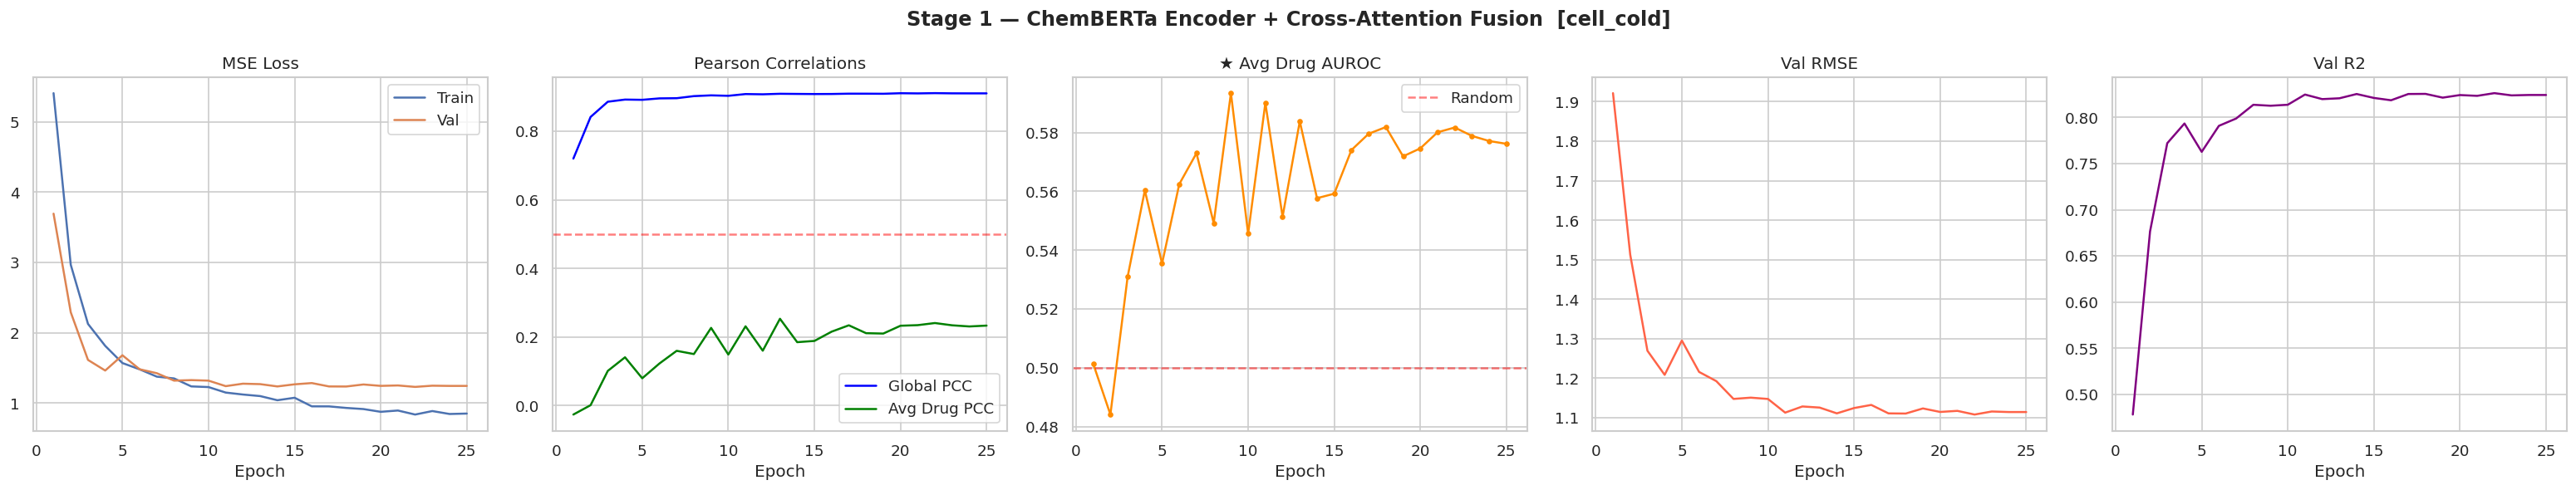

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 1 TRAINING
#  Head + cross-attention + ChemBERTa upper layers (backbone frozen).
# ═══════════════════════════════════════════════════════════════════════
section(f'8. STAGE 1 TRAINING ({CONFIG["stage1_epochs"]} epochs)  [mode: {SPLIT_MODE}]')

m = get_module(model)
trainable_s1 = [
    {'params': m.drug_encoder.parameters(),    'lr': CONFIG['stage1_lr'] * 0.1},
    {'params': m.fusion.parameters(),          'lr': CONFIG['stage1_lr']},
    {'params': m.regression_head.parameters(), 'lr': CONFIG['stage1_lr']},
]
opt_s1 = optim.AdamW(trainable_s1, weight_decay=CONFIG['stage1_wd'])

steps_per_epoch = math.ceil(len(train_loader) / CONFIG['grad_accum'])
total_steps_s1  = steps_per_epoch * CONFIG['stage1_epochs']

sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1,
    max_lr=[CONFIG['stage1_lr'] * 0.1, CONFIG['stage1_lr'], CONFIG['stage1_lr']],
    total_steps=total_steps_s1, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0)
scaler_s1 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s1   = -np.inf; patience_s1 = 0
hist_s1   = {k: [] for k in ['train_loss', 'val_loss', 'val_pcc',
                               'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2']}

print(f'Steps/epoch: {steps_per_epoch} | Total: {total_steps_s1}')
print(f'Trainable:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print()

for epoch in range(1, CONFIG['stage1_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s1, scaler_s1, True, sched_s1, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s1, scaler_s1, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)
    for k, v in zip(
        ['train_loss', 'val_loss', 'val_pcc', 'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2'],
        [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'],
         vm['avg_drug_auroc'], vm['rmse'], vm['r2']]):
        hist_s1[k].append(v)
    auroc_str = f'{vm["avg_drug_auroc"]:.4f}' if not np.isnan(vm['avg_drug_auroc']) else '  N/A'
    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={auroc_str}  RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'{time.time()-t0:.0f}s')
    if vm['pearson'] > best_s1:
        best_s1 = vm['pearson']; patience_s1 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  GlobalPCC={best_s1:.4f}  '
              f'DrugPCC={vm["avg_drug_pearson"]:.4f}  AUROC={auroc_str}')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping at epoch {epoch}'); break

print(f'\nStage 1 complete. Best GlobalPCC = {best_s1:.4f}')

E = range(1, len(hist_s1['train_loss']) + 1)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle(f'Stage 1 — ChemBERTa Encoder + Cross-Attention Fusion  [{SPLIT_MODE}]',
             fontweight='bold')
axes[0].plot(E, hist_s1['train_loss'], label='Train')
axes[0].plot(E, hist_s1['val_loss'],   label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s1['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s1['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s1['val_auroc'], color='darkorange', marker='.')
axes[2].axhline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_title('★ Avg Drug AUROC'); axes[2].legend()
axes[3].plot(E, hist_s1['val_rmse'], color='tomato'); axes[3].set_title('Val RMSE')
axes[4].plot(E, hist_s1['val_r2'],   color='purple'); axes[4].set_title('Val R2')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}stage1_curves_{SPLIT_MODE}.png', dpi=150)
plt.show()



══════════════════════════════════════════════════════════════════════
  9. STAGE 2 TRAINING (30 epochs)  [mode: cell_cold]
══════════════════════════════════════════════════════════════════════
Trainable modules (Stage 2):
  backbone.cross_layers          TRAINABLE 28391424
  backbone.fusion                TRAINABLE 6148
  drug_encoder                   TRAINABLE 296448
  fusion (drug-patient)          TRAINABLE 1825920
  regression_head                TRAINABLE 148865

Total trainable Stage 2: 30,668,805

[S2 01/30]  TrLoss=0.8270  VlLoss=1.2584  PCC=0.9094  DrugPCC=0.1968  AUROC=0.5587  RMSE=1.1218  R2=0.8221  103s
  ✓ Best saved  GlobalPCC=0.9094  DrugPCC=0.1968  AUROC=0.5587
[S2 02/30]  TrLoss=0.8688  VlLoss=1.2647  PCC=0.9097  DrugPCC=0.2503  AUROC=0.5744  RMSE=1.1246  R2=0.8212  103s
  ✓ Best saved  GlobalPCC=0.9097  DrugPCC=0.2503  AUROC=0.5744
[S2 03/30]  TrLoss=0.8869  VlLoss=1.2326  PCC=0.9117  DrugPCC=0.2609  AUROC=0.5797  RMSE=1.1102  R2=0.8257  103s
  ✓ Best saved  Globa

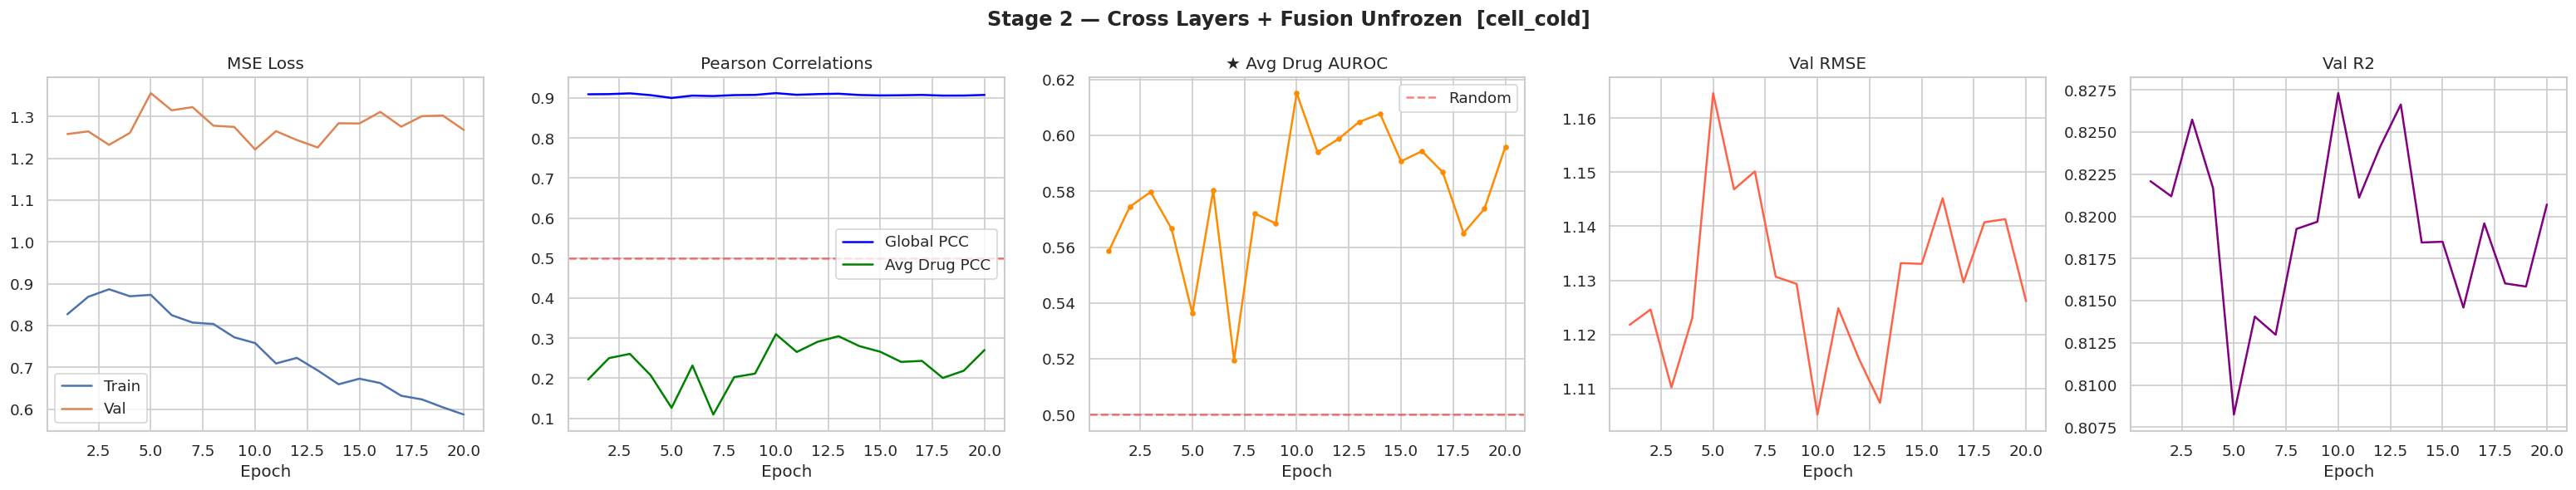

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — STAGE 2 TRAINING
#  Unfreeze backbone cross_layers + fusion; differential LRs.
# ═══════════════════════════════════════════════════════════════════════
section(f'9. STAGE 2 TRAINING ({CONFIG["stage2_epochs"]} epochs)  [mode: {SPLIT_MODE}]')

get_module(model).load_state_dict(torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))
get_module(model).freeze_backbone = False   # ← ADD THIS, the whole point of Stage 2
bm = get_module(model).backbone
for p in bm.cross_layers.parameters(): p.requires_grad = True
for p in bm.fusion.parameters():       p.requires_grad = True

print('Trainable modules (Stage 2):')
modules_s2 = {
    'backbone.cross_layers': bm.cross_layers,
    'backbone.fusion':       bm.fusion,
    'drug_encoder':          get_module(model).drug_encoder,
    'fusion (drug-patient)': get_module(model).fusion,
    'regression_head':       get_module(model).regression_head,
}
for name, mod in modules_s2.items():
    n_tr = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f'  {name:<30} {"TRAINABLE " + str(n_tr) if n_tr else "FROZEN"}')

m = get_module(model)
opt_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),       'lr': CONFIG['stage2_lr_head']},
    {'params': m.fusion.parameters(),                'lr': CONFIG['stage2_lr_head']},
    {'params': m.backbone.cross_layers.parameters(), 'lr': CONFIG['stage2_lr_cross']},
    {'params': m.backbone.fusion.parameters(),       'lr': CONFIG['stage2_lr_cross']},
    {'params': [p for p in m.drug_encoder.encoder.parameters() if p.requires_grad],
                                                      'lr': CONFIG['stage2_lr_cbert']},
    {'params': m.drug_encoder.proj.parameters(),     'lr': CONFIG['stage2_lr_head']},
], weight_decay=CONFIG['stage2_wd'])

total_steps_s2 = math.ceil(len(train_loader) / CONFIG['grad_accum']) * CONFIG['stage2_epochs']
sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[CONFIG['stage2_lr_head'],  CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross'],
            CONFIG['stage2_lr_cbert'], CONFIG['stage2_lr_head']],
    total_steps=total_steps_s2, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0)
scaler_s2 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
best_s2   = -np.inf; patience_s2 = 0
hist_s2   = {k: [] for k in ['train_loss', 'val_loss', 'val_pcc',
                               'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2']}

print(f'\nTotal trainable Stage 2: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print()

for epoch in range(1, CONFIG['stage2_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(
        model, train_loader, opt_s2, scaler_s2, True, sched_s2, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(
        model, val_loader, opt_s2, scaler_s2, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)
    for k, v in zip(
        ['train_loss', 'val_loss', 'val_pcc', 'val_drug_pcc', 'val_auroc', 'val_rmse', 'val_r2'],
        [tr_loss, vl_loss, vm['pearson'], vm['avg_drug_pearson'],
         vm['avg_drug_auroc'], vm['rmse'], vm['r2']]):
        hist_s2[k].append(v)
    auroc_str = f'{vm["avg_drug_auroc"]:.4f}' if not np.isnan(vm['avg_drug_auroc']) else '  N/A'
    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  DrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'AUROC={auroc_str}  RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'{time.time()-t0:.0f}s')
    if vm['pearson'] > best_s2:
        best_s2 = vm['pearson']; patience_s2 = 0
        torch.save(get_module(model).state_dict(), CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved  GlobalPCC={best_s2:.4f}  '
              f'DrugPCC={vm["avg_drug_pearson"]:.4f}  AUROC={auroc_str}')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping at epoch {epoch}'); break

print(f'\nStage 2 complete. Best GlobalPCC = {best_s2:.4f}')

E = range(1, len(hist_s2['train_loss']) + 1)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle(f'Stage 2 — Cross Layers + Fusion Unfrozen  [{SPLIT_MODE}]', fontweight='bold')
axes[0].plot(E, hist_s2['train_loss'], label='Train')
axes[0].plot(E, hist_s2['val_loss'],   label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, hist_s2['val_pcc'],      label='Global PCC',   color='blue')
axes[1].plot(E, hist_s2['val_drug_pcc'], label='Avg Drug PCC', color='green')
axes[1].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[1].set_title('Pearson Correlations'); axes[1].legend()
axes[2].plot(E, hist_s2['val_auroc'], color='darkorange', marker='.')
axes[2].axhline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_title('★ Avg Drug AUROC'); axes[2].legend()
axes[3].plot(E, hist_s2['val_rmse'], color='tomato'); axes[3].set_title('Val RMSE')
axes[4].plot(E, hist_s2['val_r2'],   color='purple'); axes[4].set_title('Val R2')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}stage2_curves_{SPLIT_MODE}.png', dpi=150)
plt.show()


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — EVALUATION ON TEST SET  (SPLIT_MODE)
# ═══════════════════════════════════════════════════════════════════════
section(f'10. EVALUATION — {SPLIT_MODE.upper()} TEST SET')

get_module(model).load_state_dict(
    torch.load(CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()
print('Best checkpoint loaded.')

_, te_preds, te_targets, te_drug_ids = run_epoch(
    model, test_loader, None, None, is_train=False)

te_results = compute_metrics(te_preds, te_targets, te_drug_ids, id_to_drug)
auroc_str  = f'{te_results["avg_drug_auroc"]:.4f}' if not np.isnan(te_results['avg_drug_auroc']) else '  N/A '

print(f'\n{"="*65}')
print(f'  {SPLIT_MODE.upper()} TEST SET')
print(f'{"="*65}')
print(f'  Pearson PCC:           {te_results["pearson"]:.4f}')
print(f'  Spearman SCC:          {te_results["spearman"]:.4f}')
print(f'  RMSE:                  {te_results["rmse"]:.4f}')
print(f'  R\u00b2:                    {te_results["r2"]:.4f}')
print(f'  ─── Per-drug (drugs ≥5 samples: {te_results["n_drugs_evaluated"]}) ───')
print(f'  Avg Drug Pearson:      {te_results["avg_drug_pearson"]:.4f}')
print(f'  Avg Drug Spearman:     {te_results["avg_drug_spearman"]:.4f}')
print(f'  ★ Avg Drug AUROC:      {auroc_str}')
print(f'    (AUROC valid drugs:  {te_results["n_drugs_auroc_valid"]})')



══════════════════════════════════════════════════════════════════════
  10. EVALUATION — CELL_COLD TEST SET
══════════════════════════════════════════════════════════════════════
Best checkpoint loaded.

  CELL_COLD TEST SET
  Pearson PCC:           0.9385
  Spearman SCC:          0.8912
  RMSE:                  0.9161
  R²:                    0.8790
  ─── Per-drug (drugs ≥5 samples: 71) ───
  Avg Drug Pearson:      0.2444
  Avg Drug Spearman:     0.2212
  ★ Avg Drug AUROC:      0.6090
    (AUROC valid drugs:  71)


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — SOTA COMPARISON
#  Shows OncoBridge v4 result for the active SPLIT_MODE against
#  reported numbers from prior work.
#
#  References:
#   [1] DTCDR  — Liu et al. 2024 (Bioinformatics)
#   [2] PASO   — Wang et al. 2024 (Nature Comms)
#   [3] TGSA   — Zhu et al. 2022 (Bioinformatics)
#   [4] DeepCDR— Liu et al. 2020 (Bioinformatics)
#   [5] GraphDRP— Nguyen et al. 2021 (Bioinformatics)
#   [6] MOLI   — Sharifi-Noghabi 2019 (ISMB)
#   [7] CDRscan — Chang et al. 2018
# ═══════════════════════════════════════════════════════════════════════
section('11. SOTA COMPARISON')

# SOTA reference values per split type
# Columns: (name, warm_pcc, cell_cold_pcc, drug_cold_pcc, warm_auroc, notes)
SOTA = [
    ('DTCDR [1]',    0.949, 0.867, 0.621, 0.820, 'GDSC2; mRNA+Mut+CNV'),
    ('PASO [2]',     0.941, 0.887, 0.614, None,  'GDSC2; multi-omics'),
    ('TGSA [3]',     0.920, 0.821, 0.560, None,  'GDSC2; graph drug'),
    ('DeepCDR [4]',  0.921, 0.792, None,  None,  'GDSC2; GCN drug'),
    ('GraphDRP [5]', 0.912, 0.774, None,  None,  'GDSC2; graph drug'),
    ('MOLI [6]',     0.853, 0.713, None,  None,  'GDSC2; triplet loss'),
    ('CDRscan [7]',  0.801, None,  None,  None,  'GDSC2; CNN drug'),
]

# Pick the relevant SOTA column for current SPLIT_MODE
_split_col = {'warm': 1, 'cell_cold': 2, 'drug_cold': 3}[SPLIT_MODE]
_auroc_col = 4  # warm AUROC only (standard protocol)

our_pcc   = te_results['pearson']
our_auroc = te_results['avg_drug_auroc'] if not np.isnan(te_results['avg_drug_auroc']) else None

# Insert our model at top
ob_entry = (
    'OncoBridge v4 (Ours)',
    our_pcc if SPLIT_MODE == 'warm'      else None,
    our_pcc if SPLIT_MODE == 'cell_cold' else None,
    our_pcc if SPLIT_MODE == 'drug_cold' else None,
    our_auroc if SPLIT_MODE == 'warm'    else None,
    f'GDSC2; ChemBERTa·Cross-Attn [{SPLIT_MODE}]',
)
SOTA_FULL = [ob_entry] + SOTA

def fmt(v): return f'{v:.3f}' if v is not None else '  N/R '

W = 95
print(f'\n  Active split: {SPLIT_MODE.upper()}')
print(f'{"═"*W}')
print(f'  {"Model":<28} {"Warm PCC":>10} {"CellCold":>10} {"DrugCold":>10} {"AUROC(W)":>10}  Notes')
print(f'  {"-"*(W-2)}')
for i, (name, pcc_w, pcc_cc, pcc_dc, auroc_w, note) in enumerate(SOTA_FULL):
    marker = ' ◀ OUR MODEL' if i == 0 else ''
    print(f'  {name:<28} {fmt(pcc_w):>10} {fmt(pcc_cc):>10} {fmt(pcc_dc):>10} '
          f'{fmt(auroc_w):>10}  {note}{marker}')
print(f'{"═"*W}')

# Delta vs DTCDR for the active split
dtcdr_val = SOTA[0][_split_col]
if dtcdr_val is not None:
    delta = our_pcc - dtcdr_val
    sign  = '+' if delta >= 0 else ''
    split_label = SPLIT_MODE.replace('_', '-').title()
    print(f'\n  Δ vs DTCDR [{split_label} PCC]: {our_pcc:.4f}  (DTCDR {dtcdr_val:.3f})  Δ = {sign}{delta:+.4f}')

if SPLIT_MODE == 'warm' and our_auroc is not None:
    dtcdr_auroc = 0.820
    print(f'  Δ vs DTCDR [Warm AUROC]:    {our_auroc:.4f}  (DTCDR {dtcdr_auroc:.3f})  '
          f'Δ = {our_auroc - dtcdr_auroc:+.4f}')

print()
print('  Note: PCC values from different papers may use slightly different')
print('  pre-processing and splits. Comparisons are approximate.')

# Save summary CSV
rows = [{
    'split':             SPLIT_MODE,
    'pearson':           round(te_results['pearson'],          4),
    'spearman':          round(te_results['spearman'],         4),
    'rmse':              round(te_results['rmse'],             4),
    'r2':                round(te_results['r2'],               4),
    'avg_drug_pearson':  round(te_results['avg_drug_pearson'], 4),
    'avg_drug_spearman': round(te_results['avg_drug_spearman'],4),
    'avg_drug_auroc':    round(te_results['avg_drug_auroc'],   4) if not np.isnan(te_results['avg_drug_auroc']) else None,
    'n_drugs_evaluated': te_results['n_drugs_evaluated'],
}]
summary_df = pd.DataFrame(rows)
summary_df.to_csv(f'{OUT_DIR}evaluation_summary_{SPLIT_MODE}.csv', index=False)
print(f'Saved: evaluation_summary_{SPLIT_MODE}.csv')



══════════════════════════════════════════════════════════════════════
  11. SOTA COMPARISON
══════════════════════════════════════════════════════════════════════

  Active split: CELL_COLD
═══════════════════════════════════════════════════════════════════════════════════════════════
  Model                          Warm PCC   CellCold   DrugCold   AUROC(W)  Notes
  ---------------------------------------------------------------------------------------------
  OncoBridge v4 (Ours)               N/R       0.939       N/R        N/R   GDSC2; ChemBERTa·Cross-Attn [cell_cold] ◀ OUR MODEL
  DTCDR [1]                         0.949      0.867      0.621      0.820  GDSC2; mRNA+Mut+CNV
  PASO [2]                          0.941      0.887      0.614       N/R   GDSC2; multi-omics
  TGSA [3]                          0.920      0.821      0.560       N/R   GDSC2; graph drug
  DeepCDR [4]                       0.921      0.792       N/R        N/R   GDSC2; GCN drug
  GraphDRP [5]               


══════════════════════════════════════════════════════════════════════
  12. VISUALISATIONS
══════════════════════════════════════════════════════════════════════


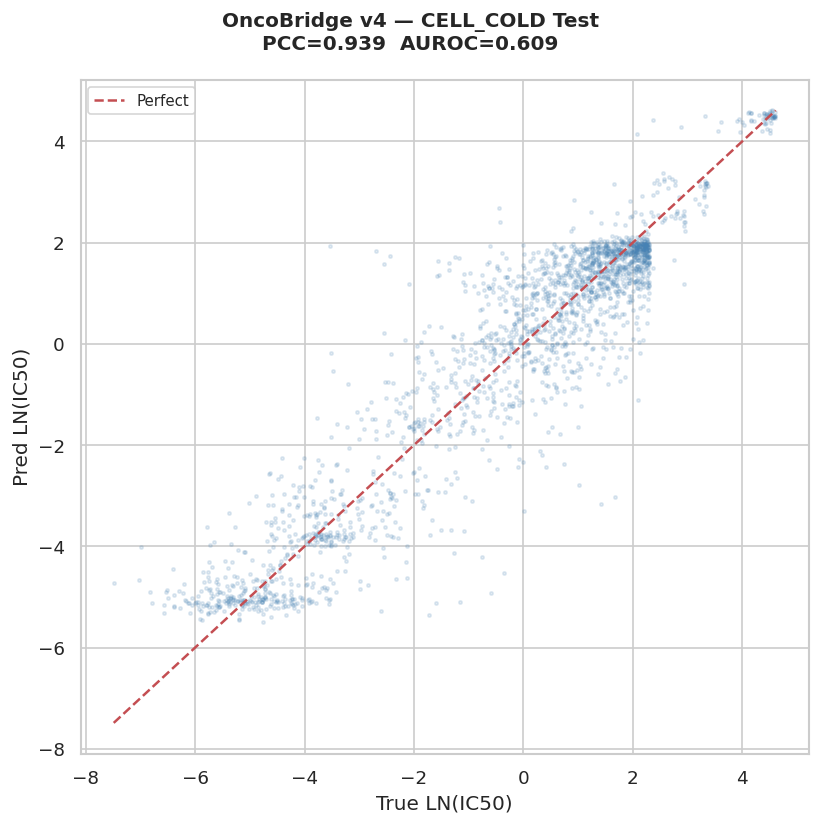

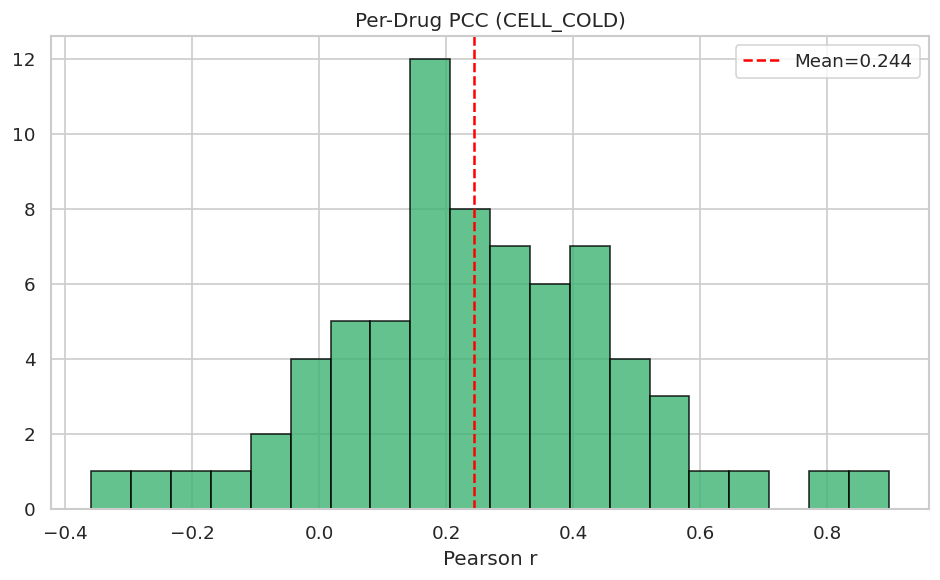

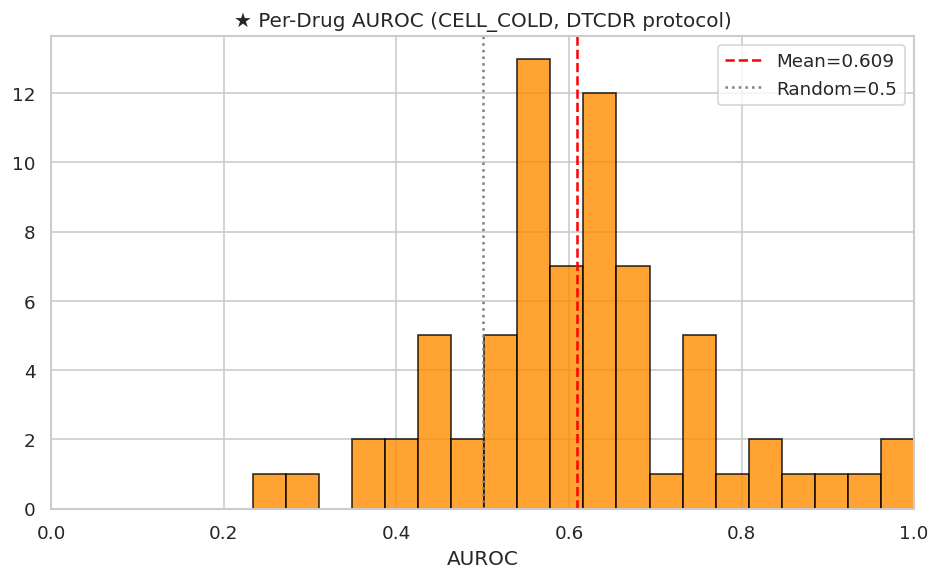

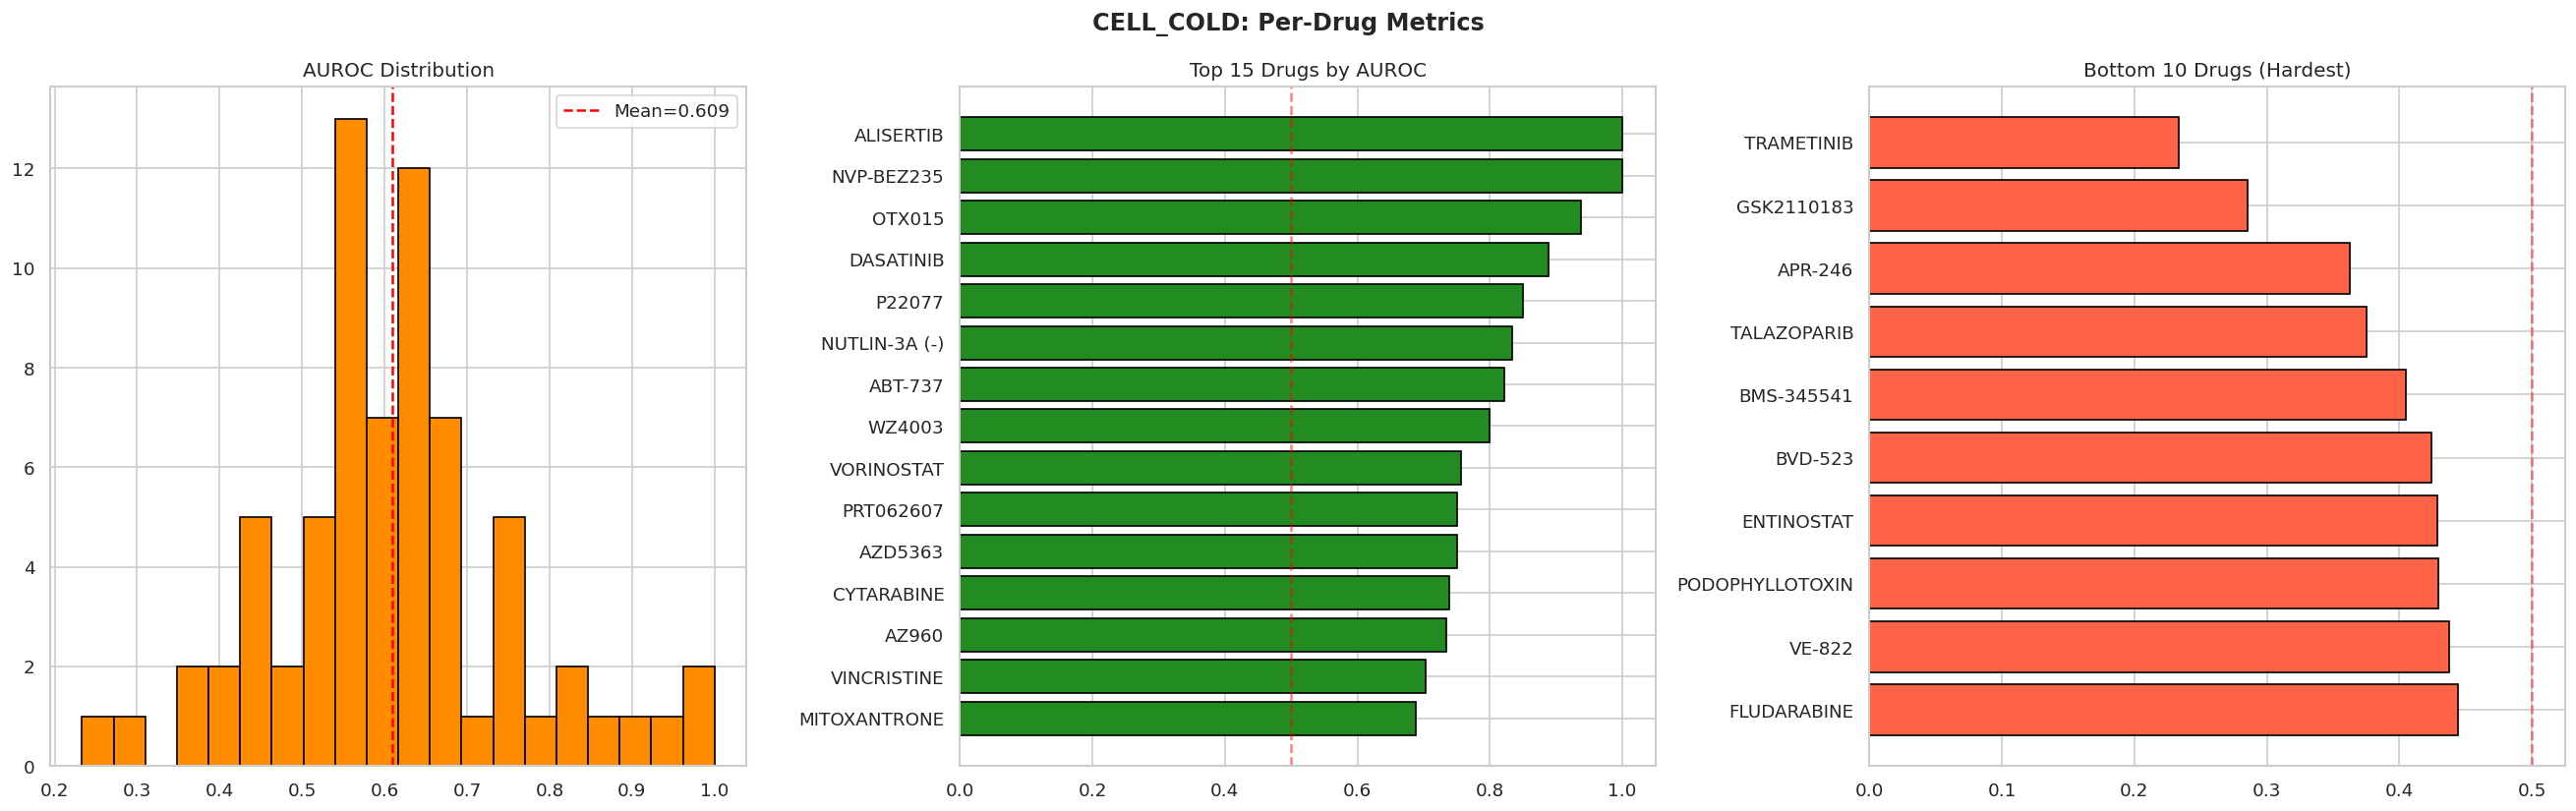

Saved: per_drug_metrics_cell_cold.csv  (71 drugs)

Top 20 drugs (CELL_COLD, sorted by AUROC):
                pearson   auroc  n_samples
ALISERTIB        0.6016  1.0000        7.0
NVP-BEZ235       0.8218  1.0000       16.0
OTX015           0.8971  0.9375        8.0
DASATINIB        0.3238  0.8889        6.0
P22077           0.4977  0.8500        9.0
NUTLIN-3A (-)    0.6612  0.8333        5.0
ABT-737          0.5157  0.8214       28.0
WZ4003           0.4884  0.8000       11.0
VORINOSTAT       0.5437  0.7570       61.0
PRT062607        0.0098  0.7500       15.0
AZD5363          0.0471  0.7500        8.0
CYTARABINE       0.4440  0.7381       13.0
AZ960            0.1645  0.7337       26.0
VINCRISTINE      0.4007  0.7036       45.0
MITOXANTRONE     0.4308  0.6886       34.0
CAMPTOTHECIN     0.2610  0.6758       32.0
5-FLUOROURACIL   0.4513  0.6667        5.0
LEFLUNOMIDE      0.5593  0.6667        6.0
AZD6738          0.3309  0.6619       29.0
TOPOTECAN        0.3381  0.6601       45.0

Bo

In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — VISUALISATIONS  (active SPLIT_MODE test set)
# ═══════════════════════════════════════════════════════════════════════
section('12. VISUALISATIONS')

from sklearn.metrics import roc_curve

auroc_val = te_results['avg_drug_auroc']
auroc_str = f'{auroc_val:.3f}' if not np.isnan(auroc_val) else 'N/A'

# ── 1. Scatter: true vs predicted IC50 ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
fig.suptitle(
    f'OncoBridge v4 — {SPLIT_MODE.upper()} Test\n'
    f'PCC={te_results["pearson"]:.3f}  AUROC={auroc_str}',
    fontweight='bold', fontsize=12)
ax.scatter(te_targets, te_preds, alpha=0.15, s=4, c='steelblue', rasterized=True)
mn = min(te_targets.min(), te_preds.min())
mx = max(te_targets.max(), te_preds.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('True LN(IC50)'); ax.set_ylabel('Pred LN(IC50)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}scatter_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 2. Per-Drug PCC Distribution ─────────────────────────────────────
drug_pccs = [v['pearson'] for v in te_results['per_drug'].values()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(drug_pccs, bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(drug_pccs), color='red', ls='--',
           label=f'Mean={np.mean(drug_pccs):.3f}')
ax.set_title(f'Per-Drug PCC ({SPLIT_MODE.upper()})')
ax.set_xlabel('Pearson r'); ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_pcc_dist_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 3. Per-Drug AUROC Distribution ───────────────────────────────────
auroc_vals = [v['auroc'] for v in te_results['per_drug'].values()
              if not np.isnan(v['auroc'])]
mean_auc = np.mean(auroc_vals) if auroc_vals else 0.0
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(auroc_vals, bins=20, color='darkorange', edgecolor='black', alpha=0.8)
ax.axvline(mean_auc, color='red', ls='--', label=f'Mean={mean_auc:.3f}')
ax.axvline(0.5, color='grey', ls=':', label='Random=0.5')
ax.set_title(f'★ Per-Drug AUROC ({SPLIT_MODE.upper()}, DTCDR protocol)')
ax.set_xlabel('AUROC'); ax.set_xlim(0, 1); ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_auroc_dist_{SPLIT_MODE}.png', dpi=150)
plt.show()

# ── 4. Top / Bottom drugs by AUROC ───────────────────────────────────
drug_df = pd.DataFrame(te_results['per_drug']).T
drug_df = drug_df[drug_df['auroc'].notna()].copy()
drug_df = drug_df.sort_values('auroc', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'{SPLIT_MODE.upper()}: Per-Drug Metrics', fontweight='bold')
axes[0].hist(drug_df['auroc'].astype(float), bins=20,
             color='darkorange', edgecolor='black')
axes[0].axvline(drug_df['auroc'].astype(float).mean(), color='red', ls='--',
                label=f'Mean={drug_df["auroc"].astype(float).mean():.3f}')
axes[0].set_title('AUROC Distribution'); axes[0].legend()

top15 = drug_df['auroc'].astype(float).nlargest(15)
axes[1].barh(top15.index, top15.values, color='forestgreen', edgecolor='black')
axes[1].set_title('Top 15 Drugs by AUROC'); axes[1].invert_yaxis()
axes[1].axvline(0.5, color='red', ls='--', alpha=0.5)

bot10 = drug_df['auroc'].astype(float).nsmallest(10)
axes[2].barh(bot10.index, bot10.values, color='tomato', edgecolor='black')
axes[2].set_title('Bottom 10 Drugs (Hardest)'); axes[2].invert_yaxis()
axes[2].axvline(0.5, color='red', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_auroc_ranking_{SPLIT_MODE}.png', dpi=150)
plt.show()

# Save per-drug metrics CSV
drug_df.to_csv(f'{OUT_DIR}per_drug_metrics_{SPLIT_MODE}.csv')
print(f'Saved: per_drug_metrics_{SPLIT_MODE}.csv  ({len(drug_df)} drugs)')

print(f'\nTop 20 drugs ({SPLIT_MODE.upper()}, sorted by AUROC):')
print(drug_df[['pearson', 'auroc', 'n_samples']].head(20).round(4).to_string())
print(f'\nBottom 10 drugs ({SPLIT_MODE.upper()}, lowest AUROC):')
print(drug_df[['pearson', 'auroc', 'n_samples']].tail(10).round(4).to_string())



══════════════════════════════════════════════════════════════════════
  13. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation on CELL_COLD test set...
  Setting                                    DrugPCC  GlobalPCC    RMSE      R2    AUROC
  -------------------------------------------------------------------------------------
  All 4 modalities (full model)               0.2443     0.9385  0.9160  0.8790   0.6091
  No mRNA                                     0.1007     0.9302  0.9789  0.8618   0.5498
  No CNV                                      0.1888     0.9369  0.9383  0.8731   0.5783
  No Mutation                                 0.2415     0.9325  0.9530  0.8690   0.6110
  No Methylation                              0.2125     0.9343  0.9445  0.8714   0.5881
  mRNA only                                   0.1895     0.9293  0.9815  0.8611   0.5638
  mRNA + CNV only                             0.2005     0.9260  0.9961  0.8569   0

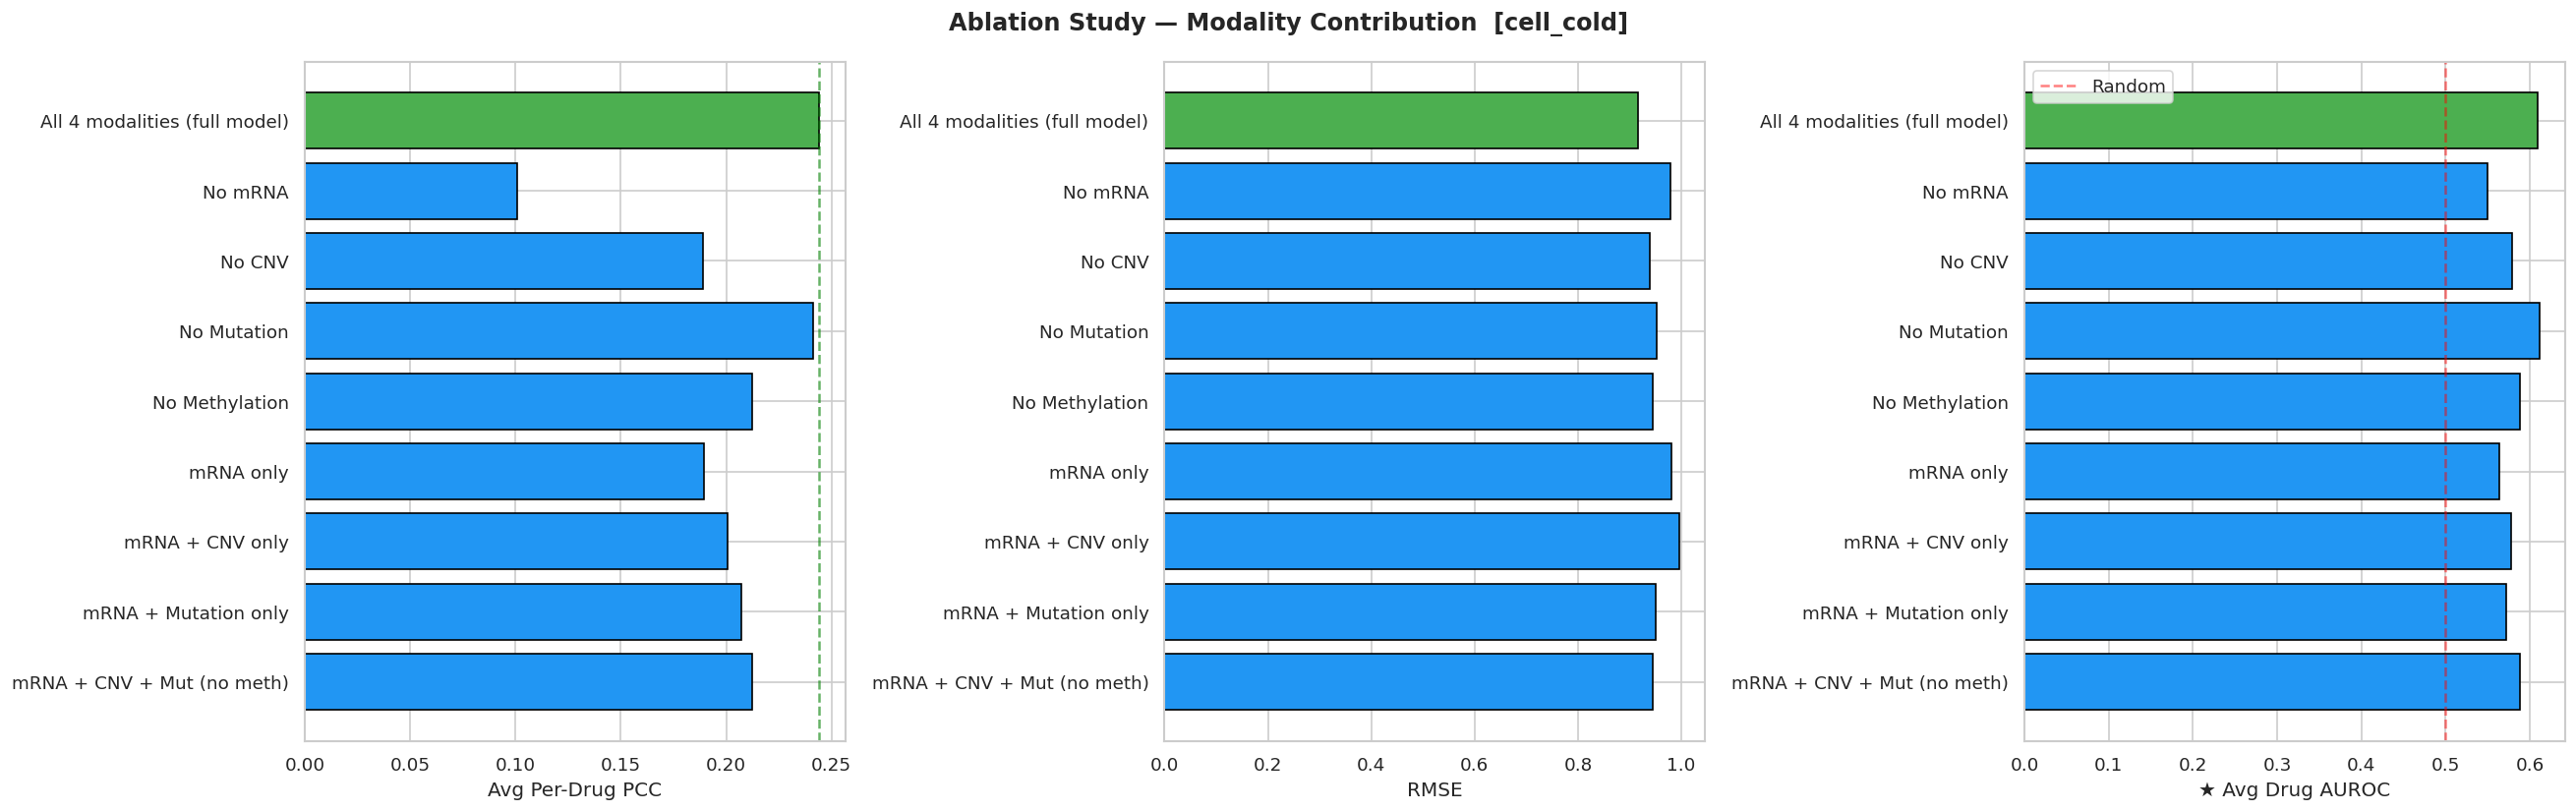

Saved: ablation_results_cell_cold.csv


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — ABLATION STUDY  (modality zeroing on active test set)
# ═══════════════════════════════════════════════════════════════════════
section('13. ABLATION STUDY')

def ablation_eval(model, loader, zero_mods=None):
    model.eval(); all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for b in loader:
            mrna = b['mrna'].to(DEVICE); cnv  = b['cnv'].to(DEVICE)
            mut  = b['mut'].to(DEVICE);  meth = b['meth'].to(DEVICE)
            ids  = b['input_ids'].to(DEVICE); mask = b['attention_mask'].to(DEVICE)
            ic50 = b['ic50'].to(DEVICE)
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            pred = model(mrna, cnv, mut, meth, ids, mask).squeeze(1)
            all_p.append(pred.cpu().numpy())
            all_t.append(ic50.cpu().numpy())
            all_d.append(b['drug_idx'].numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['r2'], m['avg_drug_auroc']

ablation_configs = [
    ('All 4 modalities (full model)',  []),
    ('No mRNA',                        ['mrna']),
    ('No CNV',                         ['cnv']),
    ('No Mutation',                    ['mut']),
    ('No Methylation',                 ['meth']),
    ('mRNA only',                      ['cnv', 'mut', 'meth']),
    ('mRNA + CNV only',                ['mut', 'meth']),
    ('mRNA + Mutation only',           ['cnv', 'meth']),
    ('mRNA + CNV + Mut (no meth)',     ['meth']),
]

print(f'Running ablation on {SPLIT_MODE.upper()} test set...')
print(f'  {"Setting":<40} {"DrugPCC":>9} {"GlobalPCC":>10} {"RMSE":>7} {"R2":>7} {"AUROC":>8}')
print(f'  {"-"*85}')

abl_results = []
for name, zero_mods in ablation_configs:
    dp, gp, rmse, r2, auroc = ablation_eval(model, test_loader, zero_mods)
    auc_str = f'{auroc:.4f}' if not np.isnan(auroc) else '  N/A'
    abl_results.append({'Setting': name, 'AvgDrugPCC': round(dp, 4),
                        'GlobalPCC': round(gp, 4), 'RMSE': round(rmse, 4),
                        'R2': round(r2, 4), 'AUROC': round(auroc, 4) if not np.isnan(auroc) else None})
    print(f'  {name:<40} {dp:>9.4f} {gp:>10.4f} {rmse:>7.4f} {r2:>7.4f} {auc_str:>8}')

abl_df = pd.DataFrame(abl_results)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Ablation Study — Modality Contribution  [{SPLIT_MODE}]', fontweight='bold')
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(abl_df))]
axes[0].barh(abl_df['Setting'], abl_df['AvgDrugPCC'], color=colors, edgecolor='black')
axes[0].axvline(abl_df.iloc[0]['AvgDrugPCC'], color='green', ls='--', alpha=0.6)
axes[0].set_xlabel('Avg Per-Drug PCC'); axes[0].invert_yaxis()
axes[1].barh(abl_df['Setting'], abl_df['RMSE'], color=colors, edgecolor='black')
axes[1].set_xlabel('RMSE'); axes[1].invert_yaxis()
auroc_vals_abl = [v if v is not None else 0.0 for v in abl_df['AUROC']]
axes[2].barh(abl_df['Setting'], auroc_vals_abl, color=colors, edgecolor='black')
axes[2].axvline(0.5, color='red', ls='--', alpha=0.5, label='Random')
axes[2].set_xlabel('★ Avg Drug AUROC'); axes[2].invert_yaxis(); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ablation_study_{SPLIT_MODE}.png', dpi=150)
plt.show()
abl_df.to_csv(f'{OUT_DIR}ablation_results_{SPLIT_MODE}.csv', index=False)
print(f'Saved: ablation_results_{SPLIT_MODE}.csv')



══════════════════════════════════════════════════════════════════════
  14. DELTA IC50 — CLUSTERMAP + CANCER HEATMAP + RANKINGS
══════════════════════════════════════════════════════════════════════
Delta IC50 stats (should be centred near 0 per drug):
  Range : [-3.183, 1.547]
  Mean  : -0.0000
  Std   : 0.4013

Cancer type column: "OncotreePrimaryDisease"  (32 unique types)

Clustermap matrix: 19 drugs × 40 cell lines


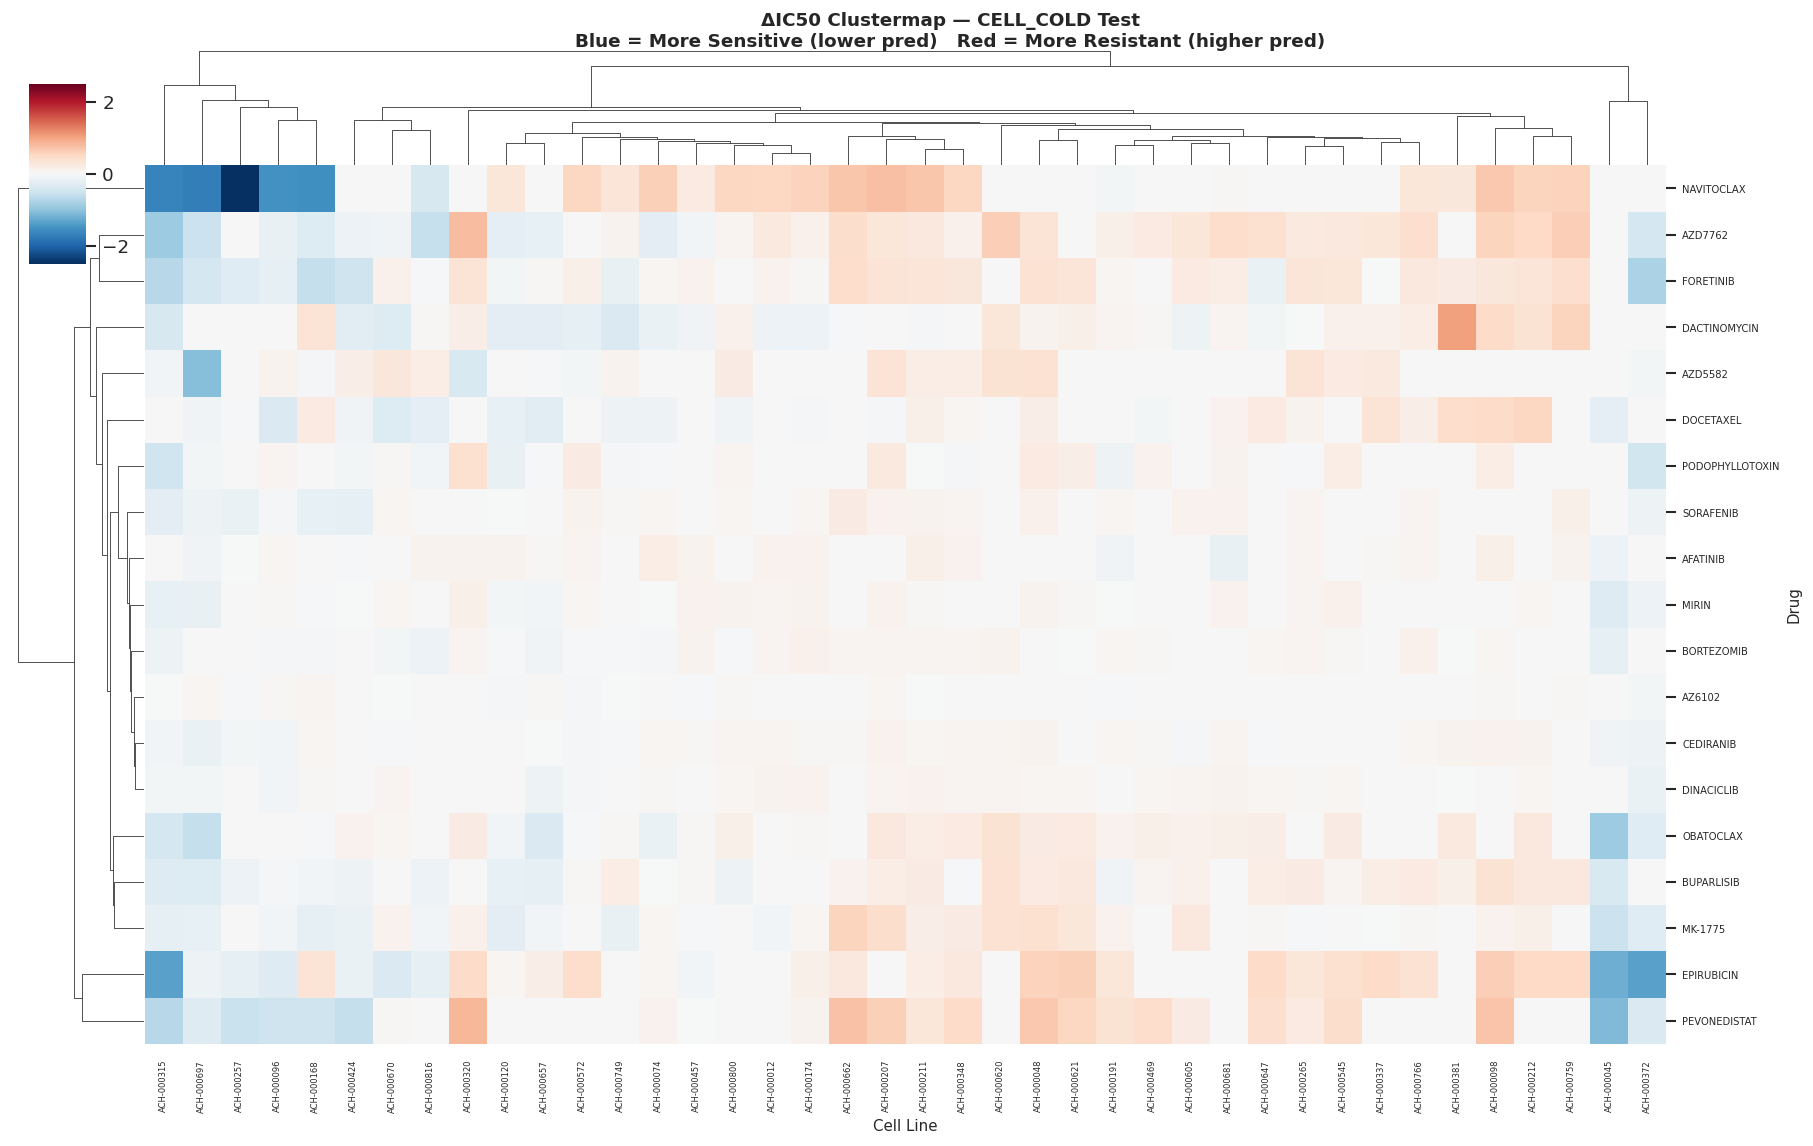

Saved: delta_ic50_heatmap_cell_cold.png


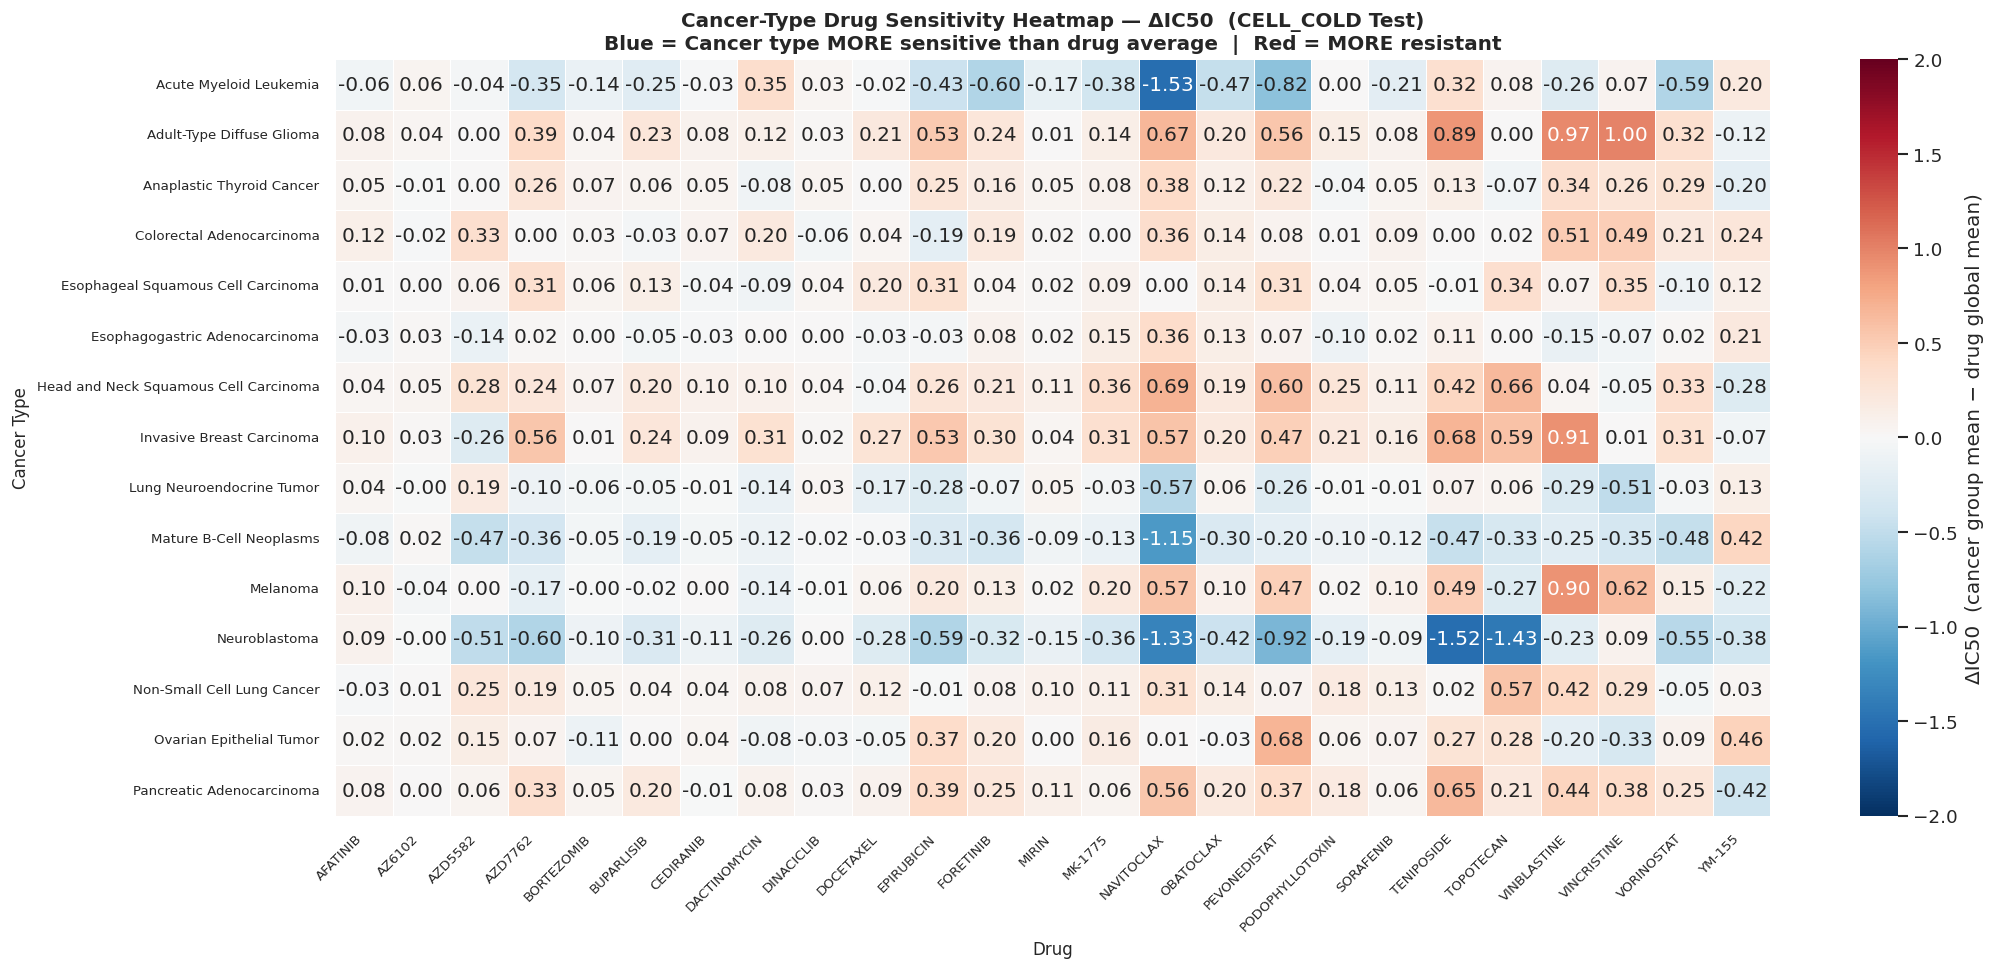

Saved: delta_ic50_heatmap_cancer_cell_cold.png

Top 5 most selectively sensitive drugs per cancer type (lowest ΔIC50 = most sensitive relative to drug global mean):
                                      cancer_type    drug_name  mean_delta_ic50  mean_pred_ic50  mean_true_ic50  std_pred_ic50  n_cell_lines
                           Acute Myeloid Leukemia      ABT-737        -2.481572       -2.257812       -4.413736            NaN             1
                           Acute Myeloid Leukemia   NAVITOCLAX        -1.525300       -0.449951        1.407568            NaN             1
                           Acute Myeloid Leukemia        AZ960        -1.100716       -0.272217       -0.867417            NaN             1
                           Acute Myeloid Leukemia PEVONEDISTAT        -0.817310       -1.183838       -2.176039       0.413975             2
                           Acute Myeloid Leukemia   IRINOTECAN        -0.611921        0.402832       -0.732305            NaN    

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — DELTA IC50 ANALYSIS: CELL-LINE CLUSTERMAP + CANCER HEATMAP
#
#  Delta_IC50 = pred_IC50 − mean(pred_IC50 for that drug across test set)
#
#  Interpretation:
#    Delta < 0  →  this cell line is MORE sensitive than average (drug works well)
#    Delta > 0  →  this cell line is MORE resistant than average
#
#  Reuses te_preds / te_targets / te_drug_ids from Cell 10 — no re-inference.
#  Rankings are sorted by mean_delta_ic50, not raw IC50.
# ═══════════════════════════════════════════════════════════════════════
section('14. DELTA IC50 — CLUSTERMAP + CANCER HEATMAP + RANKINGS')

# ── 1. Build long-form DataFrame ─────────────────────────────────────
test_reset = ic50_test.reset_index(drop=True)

delta_df = pd.DataFrame({
    'pred_ic50' : te_preds.astype(np.float64),
    'true_ic50' : te_targets.astype(np.float64),
    'drug_idx'  : te_drug_ids,
})
delta_df['drug_name'] = delta_df['drug_idx'].map(id_to_drug)
delta_df['cell_line'] = test_reset['ModelID'].values

# ── 2. Per-drug delta (global test-set mean as baseline) ─────────────
drug_mean_pred              = delta_df.groupby('drug_name')['pred_ic50'].mean()
delta_df['drug_mean_pred']  = delta_df['drug_name'].map(drug_mean_pred)
delta_df['delta_ic50']      = delta_df['pred_ic50'] - delta_df['drug_mean_pred']

print('Delta IC50 stats (should be centred near 0 per drug):')
print(f'  Range : [{delta_df["delta_ic50"].min():.3f}, {delta_df["delta_ic50"].max():.3f}]')
print(f'  Mean  : {delta_df["delta_ic50"].mean():.4f}')
print(f'  Std   : {delta_df["delta_ic50"].std():.4f}')

# ── 3. Auto-detect cancer type column ────────────────────────────────
CANCER_COL = None
for _c in ['cancer_type', 'OncotreePrimaryDisease', 'tissue', 'TissueType', 'Tissue']:
    if _c in test_reset.columns:
        CANCER_COL = _c
        print(f'\nCancer type column: "{CANCER_COL}"  '
              f'({test_reset[CANCER_COL].nunique()} unique types)')
        break
if CANCER_COL is None:
    print('\nWARNING: No cancer type column found in ic50_test.')
    print(f'Available columns: {test_reset.columns.tolist()}')

if CANCER_COL:
    delta_df['cancer_type'] = test_reset[CANCER_COL].values

# ═════════════════════════════════════════════════════════════════════
#  PLOT A — Cell-line × Drug clustermap  (original fine-grained view)
# ═════════════════════════════════════════════════════════════════════
MIN_DRUG_COVERAGE = 15
MIN_CL_COVERAGE   = 10

drug_counts = delta_df['drug_name'].value_counts()
cl_counts   = delta_df['cell_line'].value_counts()
keep_drugs  = drug_counts[drug_counts >= MIN_DRUG_COVERAGE].index
keep_cls    = cl_counts  [cl_counts   >= MIN_CL_COVERAGE ].index

filtered = delta_df[
    delta_df['drug_name'].isin(keep_drugs) &
    delta_df['cell_line'].isin(keep_cls)
]

pivot_cl = filtered.pivot_table(
    index='drug_name', columns='cell_line',
    values='delta_ic50', aggfunc='mean'
)
MAX_DRUGS, MAX_CLS = 40, 50
pivot_cl = pivot_cl.iloc[:MAX_DRUGS, :MAX_CLS]
pivot_cl = pivot_cl.dropna(axis=0, thresh=max(1, int(pivot_cl.shape[1] * 0.5)))
pivot_cl = pivot_cl.dropna(axis=1, thresh=max(1, int(pivot_cl.shape[0] * 0.5)))
pivot_cl = pivot_cl.fillna(0.0)

print(f'\nClustermap matrix: {pivot_cl.shape[0]} drugs × {pivot_cl.shape[1]} cell lines')

if pivot_cl.shape[0] < 2 or pivot_cl.shape[1] < 2:
    print('[warn] Too few rows/cols for clustermap; using plain heatmap.')
    fig, ax = plt.subplots(figsize=(max(8, pivot_cl.shape[1] * 0.4),
                                    max(6, pivot_cl.shape[0] * 0.4)))
    sns.heatmap(pivot_cl, cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
                ax=ax, linewidths=0, cbar_kws={'shrink': 0.5})
    ax.set_title(f'ΔIC50 — Cell-Line View ({SPLIT_MODE.upper()} Test)\n'
                 'Blue = Sensitive   Red = Resistant', fontweight='bold')
    plt.tight_layout()
else:
    g = sns.clustermap(
        pivot_cl, cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
        figsize=(max(16, pivot_cl.shape[1] * 0.28),
                 max(10, pivot_cl.shape[0] * 0.35)),
        row_cluster=True, col_cluster=True,
        xticklabels=True, yticklabels=True,
        dendrogram_ratio=(0.08, 0.12),
        cbar_pos=(0.02, 0.80, 0.03, 0.15),
        linewidths=0,
    )
    g.ax_heatmap.set_xlabel('Cell Line', fontsize=9)
    g.ax_heatmap.set_ylabel('Drug', fontsize=9)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=5, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6, rotation=0)
    g.fig.suptitle(
        f'ΔIC50 Clustermap — {SPLIT_MODE.upper()} Test\n'
        'Blue = More Sensitive (lower pred)   Red = More Resistant (higher pred)',
        y=1.01, fontweight='bold', fontsize=11)

plt.savefig(f'{OUT_DIR}delta_ic50_heatmap_{SPLIT_MODE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: delta_ic50_heatmap_{SPLIT_MODE}.png')

# ═════════════════════════════════════════════════════════════════════
#  PLOT B — Cancer-type × Drug heatmap  (mean delta_ic50 per group)
# ═════════════════════════════════════════════════════════════════════
if CANCER_COL:
    # Top cancers by number of test pairs; top drugs by coverage
    TOP_N_CANCERS = 15
    TOP_N_DRUGS   = 25

    top_cancers = delta_df['cancer_type'].value_counts().head(TOP_N_CANCERS).index
    top_drugs_cv = delta_df['drug_name'].value_counts().head(TOP_N_DRUGS).index

    pivot_cancer = (
        delta_df[
            delta_df['cancer_type'].isin(top_cancers) &
            delta_df['drug_name'].isin(top_drugs_cv)
        ]
        .groupby(['cancer_type', 'drug_name'])['delta_ic50']
        .mean()
        .unstack(fill_value=0.0)
    )

    if pivot_cancer.empty:
        print('WARNING: cancer × drug pivot is empty — check column values.')
    else:
        plt.figure(figsize=(max(18, len(top_drugs_cv) * 0.7),
                             max(7,  len(top_cancers)  * 0.55)))
        sns.heatmap(
            pivot_cancer,
            cmap='RdBu_r', center=0, vmin=-2.0, vmax=2.0,
            annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label': 'ΔIC50  (cancer group mean − drug global mean)'},
        )
        plt.title(
            f'Cancer-Type Drug Sensitivity Heatmap — ΔIC50  ({SPLIT_MODE.upper()} Test)\n'
            'Blue = Cancer type MORE sensitive than drug average  |  '
            'Red = MORE resistant',
            fontsize=12, fontweight='bold'
        )
        plt.xlabel('Drug', fontsize=10)
        plt.ylabel('Cancer Type', fontsize=10)
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}delta_ic50_heatmap_cancer_{SPLIT_MODE}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: delta_ic50_heatmap_cancer_{SPLIT_MODE}.png')

# ═════════════════════════════════════════════════════════════════════
#  RANKINGS — Top 5 most selectively sensitive drugs per cancer type
#  Sorted by mean_delta_ic50 ascending (most negative = most selective)
# ═════════════════════════════════════════════════════════════════════
if CANCER_COL:
    drug_ranking = (
        delta_df
        .groupby(['cancer_type', 'drug_name'])
        .agg(
            mean_delta_ic50 = ('delta_ic50',  'mean'),   # ← rank by THIS
            mean_pred_ic50  = ('pred_ic50',   'mean'),
            mean_true_ic50  = ('true_ic50',   'mean'),
            std_pred_ic50   = ('pred_ic50',   'std'),
            n_cell_lines    = ('cell_line',   'nunique'),
        )
        .reset_index()
    )

    top5_per_cancer = (
        drug_ranking
        .sort_values(['cancer_type', 'mean_delta_ic50'])   # delta, not raw IC50
        .groupby('cancer_type')
        .head(5)
    )

    print('\nTop 5 most selectively sensitive drugs per cancer type '
          '(lowest ΔIC50 = most sensitive relative to drug global mean):')
    print(top5_per_cancer.to_string(index=False))
    top5_per_cancer.to_csv(f'{OUT_DIR}drug_rankings_delta_{SPLIT_MODE}.csv', index=False)
    print(f'\nSaved: drug_rankings_delta_{SPLIT_MODE}.csv')

# ── Top 10 extreme pairs (cell-line level) ────────────────────────────
delta_df_sorted = delta_df.sort_values('delta_ic50')
print('\nTop 10 most SENSITIVE cell-drug pairs (most negative ΔIC50):')
print(delta_df_sorted[['cell_line', 'drug_name', 'true_ic50', 'pred_ic50', 'delta_ic50']]
      .head(10).round(4).to_string(index=False))
print('\nTop 10 most RESISTANT cell-drug pairs (most positive ΔIC50):')
print(delta_df_sorted[['cell_line', 'drug_name', 'true_ic50', 'pred_ic50', 'delta_ic50']]
      .tail(10).round(4).to_string(index=False))

# ── Save full table ───────────────────────────────────────────────────
delta_df.to_csv(f'{OUT_DIR}delta_ic50_{SPLIT_MODE}.csv', index=False)
print(f'\nSaved: delta_ic50_{SPLIT_MODE}.csv')

print('\n' + '='*70)
print('  CELL 14 COMPLETE')
print(f'  Test pairs:      {len(delta_df):,}')
if CANCER_COL:
    print(f'  Cancer types:    {delta_df["cancer_type"].nunique()}')
    print(f'  Drugs ranked:    {drug_ranking["drug_name"].nunique()}')
print('='*70)


══════════════════════════════════════════════════════════════════════
  15. SENSITIVITY RANK CONCORDANCE
══════════════════════════════════════════════════════════════════════
Drugs evaluated: 65

Rank Spearman ρ:
  Mean   : 0.1994
  Median : 0.2111
  Std    : 0.2160
  % > 0.5: 4.6%
  % > 0.7: 3.1%

Top-5 Sensitive Recall:
  Mean   : 0.2156
  Median : 0.2000


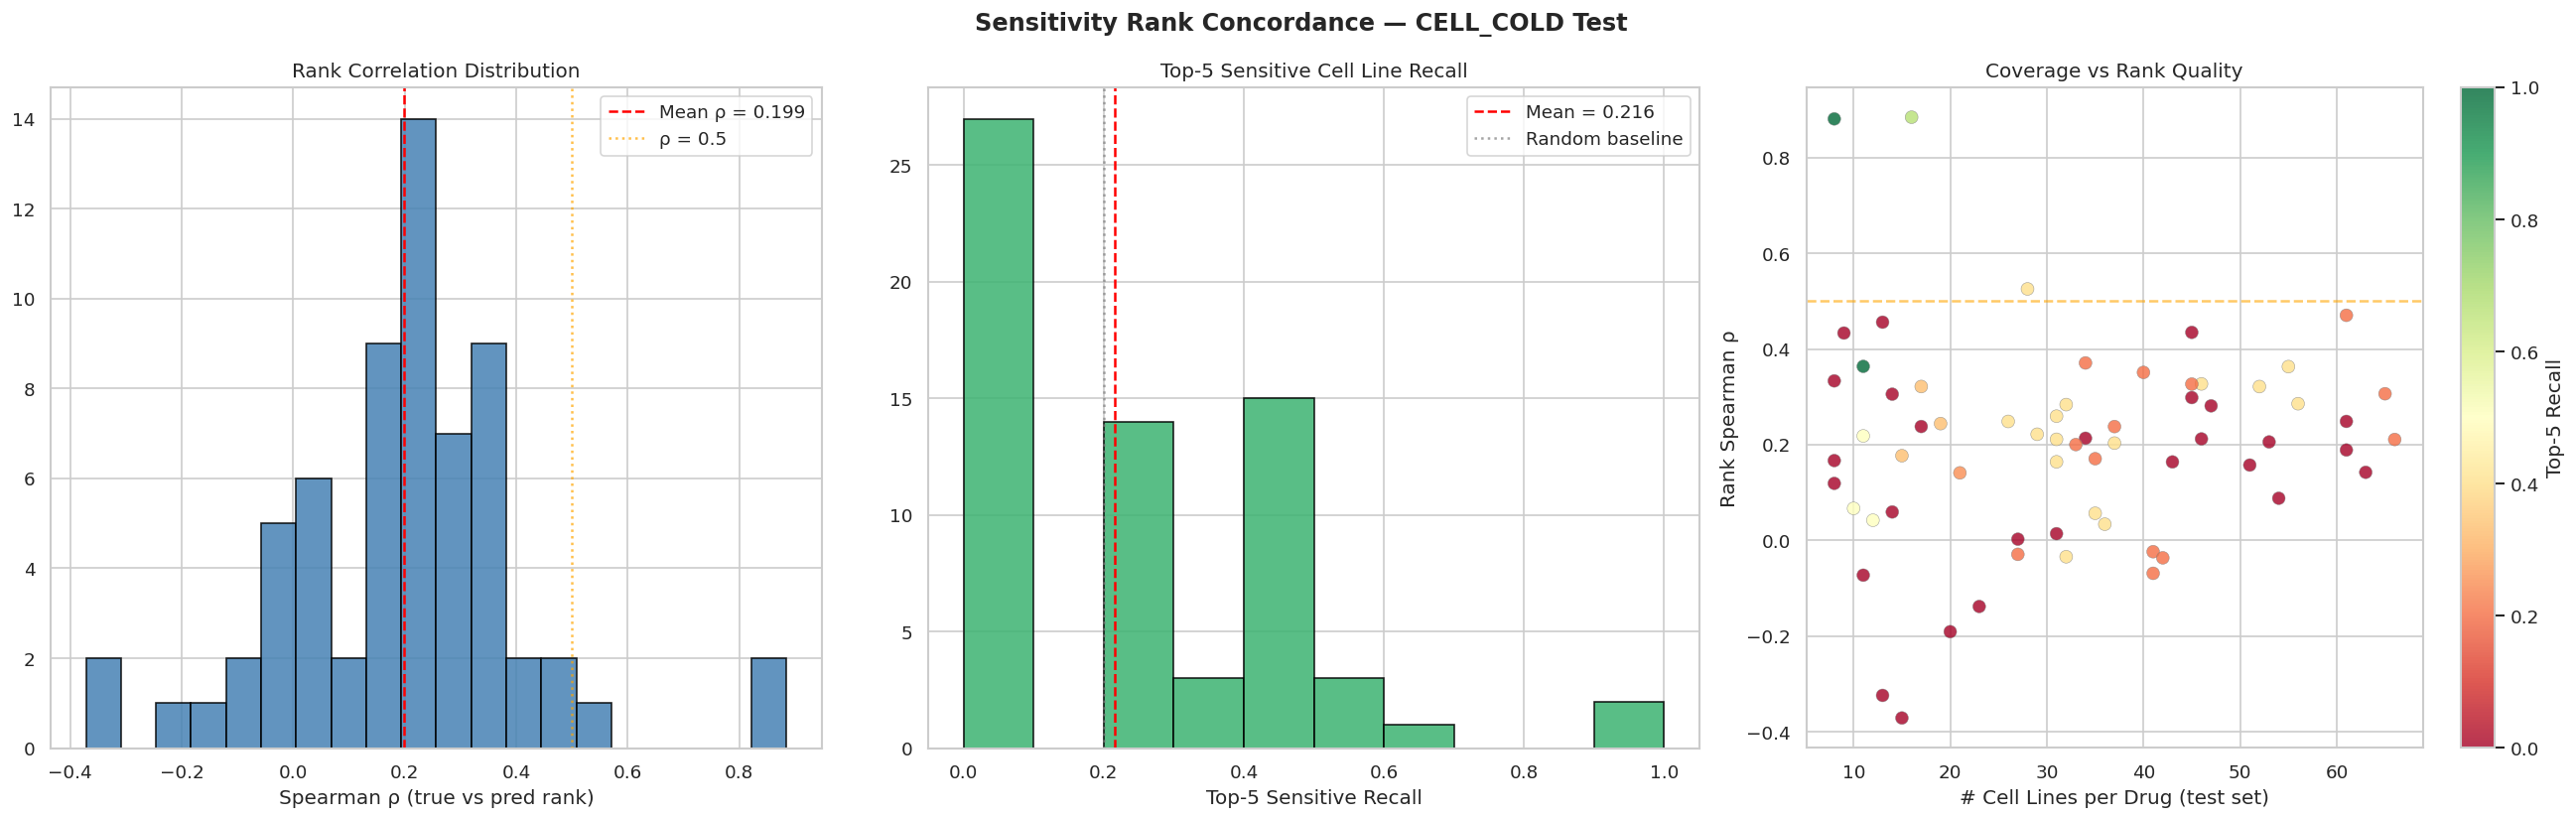


Top 10 drugs (best rank concordance):
        drug  n_cell_lines  rank_rho  topk_recall
  NVP-BEZ235            16    0.8845       0.6667
      OTX015             8    0.8810       1.0000
     ABT-737            28    0.5255       0.4000
  VORINOSTAT            61    0.4704       0.2000
  CYTARABINE            13    0.4560       0.0000
 VINCRISTINE            45    0.4347       0.0000
      P22077             9    0.4333       0.0000
MITOXANTRONE            34    0.3708       0.2000
 OXALIPLATIN            11    0.3636       1.0000
     MK-1775            55    0.3631       0.4000

Bottom 10 drugs (worst rank concordance):
           drug  n_cell_lines  rank_rho  topk_recall
         AZ6102            41   -0.0238          0.2
         AUY922            27   -0.0293          0.2
     NVP-ADW742            32   -0.0343          0.4
       AFATINIB            42   -0.0366          0.2
PODOPHYLLOTOXIN            41   -0.0690          0.2
     TRAMETINIB            11   -0.0729          0

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — SENSITIVITY RANK CONCORDANCE
#
#  For each drug: rank all cell lines by TRUE IC50 and by PREDICTED IC50.
#  Compare rankings → Spearman rank correlation per drug.
#
#  Also computes: % of top-K sensitive cell lines correctly identified.
#
#  NOTE: delta_df is built in Cell 14 (pred_ic50 / true_ic50 as float64).
# ═══════════════════════════════════════════════════════════════════════
section('15. SENSITIVITY RANK CONCORDANCE')

from scipy.stats import spearmanr

TOP_K = 5

rank_records = []
for drug_name, grp in delta_df.groupby('drug_name'):
    if len(grp) < 8:
        continue

    # Ensure float64 before ranking (guards against float32 pandas bug)
    grp = grp.copy()
    grp['true_ic50'] = grp['true_ic50'].astype(np.float64)
    grp['pred_ic50'] = grp['pred_ic50'].astype(np.float64)

    true_ranks = grp['true_ic50'].rank()
    pred_ranks = grp['pred_ic50'].rank()
    rho, pval  = spearmanr(true_ranks, pred_ranks)

    k = min(TOP_K, max(1, len(grp) // 5))
    true_top_k = set(grp.nsmallest(k, 'true_ic50').index)
    pred_top_k = set(grp.nsmallest(k, 'pred_ic50').index)
    topk_recall = len(true_top_k & pred_top_k) / k

    rank_records.append({
        'drug':         drug_name,
        'n_cell_lines': len(grp),
        'rank_rho':     round(rho,  4),
        'rank_pval':    round(pval, 4),
        'topk_recall':  round(topk_recall, 4),
        'k_used':       k,
    })

rank_df = pd.DataFrame(rank_records).sort_values('rank_rho', ascending=False)

print(f'Drugs evaluated: {len(rank_df)}')
print(f'\nRank Spearman ρ:')
print(f'  Mean   : {rank_df["rank_rho"].mean():.4f}')
print(f'  Median : {rank_df["rank_rho"].median():.4f}')
print(f'  Std    : {rank_df["rank_rho"].std():.4f}')
print(f'  % > 0.5: {(rank_df["rank_rho"] > 0.5).mean()*100:.1f}%')
print(f'  % > 0.7: {(rank_df["rank_rho"] > 0.7).mean()*100:.1f}%')
print(f'\nTop-{TOP_K} Sensitive Recall:')
print(f'  Mean   : {rank_df["topk_recall"].mean():.4f}')
print(f'  Median : {rank_df["topk_recall"].median():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Sensitivity Rank Concordance — {SPLIT_MODE.upper()} Test',
             fontweight='bold')

axes[0].hist(rank_df['rank_rho'], bins=20, color='steelblue',
             edgecolor='black', alpha=0.85)
axes[0].axvline(rank_df['rank_rho'].mean(), color='red', ls='--',
                label=f'Mean ρ = {rank_df["rank_rho"].mean():.3f}')
axes[0].axvline(0.5, color='orange', ls=':', alpha=0.7, label='ρ = 0.5')
axes[0].set_xlabel('Spearman ρ (true vs pred rank)')
axes[0].set_title('Rank Correlation Distribution')
axes[0].legend()

axes[1].hist(rank_df['topk_recall'], bins=10, color='mediumseagreen',
             edgecolor='black', alpha=0.85)
axes[1].axvline(rank_df['topk_recall'].mean(), color='red', ls='--',
                label=f'Mean = {rank_df["topk_recall"].mean():.3f}')
axes[1].axvline(1/TOP_K, color='grey', ls=':', alpha=0.7, label='Random baseline')
axes[1].set_xlabel(f'Top-{TOP_K} Sensitive Recall')
axes[1].set_title(f'Top-{TOP_K} Sensitive Cell Line Recall')
axes[1].legend()

sc = axes[2].scatter(
    rank_df['n_cell_lines'], rank_df['rank_rho'],
    c=rank_df['topk_recall'], cmap='RdYlGn',
    vmin=0, vmax=1, s=60, alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(sc, ax=axes[2], label=f'Top-{TOP_K} Recall')
axes[2].axhline(0.5, color='orange', ls='--', alpha=0.6)
axes[2].set_xlabel('# Cell Lines per Drug (test set)')
axes[2].set_ylabel('Rank Spearman ρ')
axes[2].set_title('Coverage vs Rank Quality')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}rank_concordance_{SPLIT_MODE}.png', dpi=150)
plt.show()

print(f'\nTop 10 drugs (best rank concordance):')
print(rank_df[['drug', 'n_cell_lines', 'rank_rho', 'topk_recall']].head(10).to_string(index=False))
print(f'\nBottom 10 drugs (worst rank concordance):')
print(rank_df[['drug', 'n_cell_lines', 'rank_rho', 'topk_recall']].tail(10).to_string(index=False))

rank_df.to_csv(f'{OUT_DIR}rank_concordance_{SPLIT_MODE}.csv', index=False)
print(f'\nSaved: rank_concordance_{SPLIT_MODE}.csv')



══════════════════════════════════════════════════════════════════════
  16. DRUG EMBEDDING PCA
══════════════════════════════════════════════════════════════════════
Encoding 74 unique drugs through ChemBERTa...
Embedding matrix: (74, 384)
PCA explained variance: PC1=14.5%  PC2=11.9%


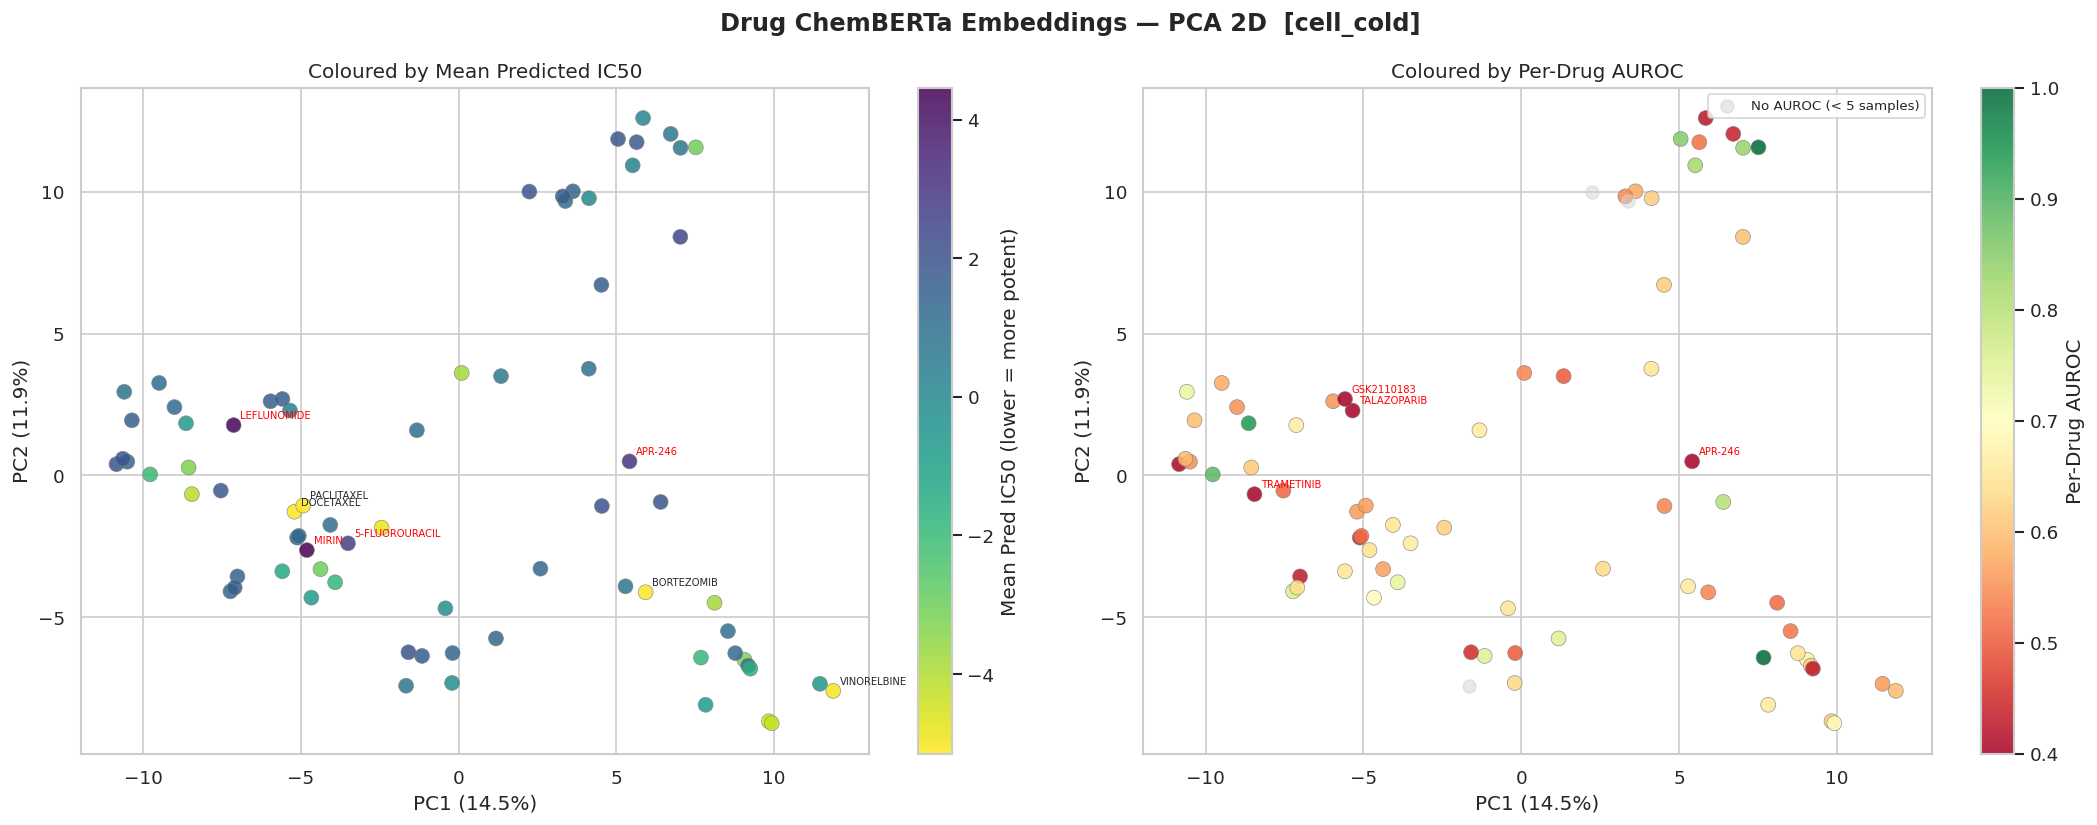

Saved: drug_embeddings_pca_cell_cold.csv

Drugs with lowest AUROC (model struggles to rank these):
      drug_name  mean_pred_ic50  auroc
     TRAMETINIB         -4.0676 0.2333
     GSK2110183          1.6653 0.2857
        APR-246          3.0424 0.3627
    TALAZOPARIB          0.3491 0.3750
     BMS-345541          1.9550 0.4050
        BVD-523          0.1239 0.4242
     ENTINOSTAT          1.4425 0.4290
PODOPHYLLOTOXIN         -1.5916 0.4298


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — DRUG EMBEDDING PCA
#
#  Extracts ChemBERTa [CLS] embedding for every drug in the test set,
#  projects to 2D via PCA, coloured by mean predicted IC50 and AUROC.
# ═══════════════════════════════════════════════════════════════════════
section('16. DRUG EMBEDDING PCA')

from sklearn.decomposition import PCA

m_mod = get_module(model)
m_mod.eval()

unique_drugs = delta_df[['drug_name']].drop_duplicates()
unique_drugs['smiles'] = unique_drugs['drug_name'].map(
    lambda d: smiles_map.get(d, 'C') or 'C')

print(f'Encoding {len(unique_drugs)} unique drugs through ChemBERTa...')

embed_list, name_list = [], []
EMBED_BS = 64

with torch.no_grad():
    for start in range(0, len(unique_drugs), EMBED_BS):
        chunk = unique_drugs.iloc[start: start + EMBED_BS]
        enc = tokenizer(
            chunk['smiles'].tolist(),
            max_length=CONFIG['chemberta_max_len'],
            padding='max_length', truncation=True, return_tensors='pt')
        ids_  = enc['input_ids'].to(DEVICE)
        mask_ = enc['attention_mask'].to(DEVICE)
        emb   = m_mod.drug_encoder(ids_, mask_).cpu().numpy()
        embed_list.append(emb)
        name_list.extend(chunk['drug_name'].tolist())

embed_matrix = np.vstack(embed_list)
print(f'Embedding matrix: {embed_matrix.shape}')

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embed_matrix)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

embed_df = pd.DataFrame({
    'drug_name': name_list,
    'pc1': coords[:, 0],
    'pc2': coords[:, 1],
})

drug_stats = delta_df.groupby('drug_name').agg(
    mean_pred_ic50=('pred_ic50', 'mean'),
    mean_true_ic50=('true_ic50', 'mean'),
).reset_index()

auroc_lookup = {name: vals['auroc'] for name, vals in te_results['per_drug'].items()}
drug_stats['auroc'] = drug_stats['drug_name'].map(auroc_lookup)

embed_df = embed_df.merge(drug_stats, on='drug_name', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Drug ChemBERTa Embeddings — PCA 2D  [{SPLIT_MODE}]',
             fontweight='bold')

sc1 = axes[0].scatter(
    embed_df['pc1'], embed_df['pc2'],
    c=embed_df['mean_pred_ic50'], cmap='viridis_r',
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.4)
plt.colorbar(sc1, ax=axes[0], label='Mean Pred IC50 (lower = more potent)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Coloured by Mean Predicted IC50')
for _, row in embed_df.nsmallest(4, 'mean_pred_ic50').iterrows():
    axes[0].annotate(row['drug_name'], (row['pc1'], row['pc2']),
                     fontsize=6, xytext=(4, 4), textcoords='offset points')
for _, row in embed_df.nlargest(4, 'mean_pred_ic50').iterrows():
    axes[0].annotate(row['drug_name'], (row['pc1'], row['pc2']),
                     fontsize=6, color='red', xytext=(4, 4), textcoords='offset points')

valid_auroc = embed_df.dropna(subset=['auroc'])
sc2 = axes[1].scatter(
    valid_auroc['pc1'], valid_auroc['pc2'],
    c=valid_auroc['auroc'], cmap='RdYlGn',
    vmin=0.4, vmax=1.0,
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.4)
no_auroc = embed_df[embed_df['auroc'].isna()]
axes[1].scatter(no_auroc['pc1'], no_auroc['pc2'],
                color='lightgrey', s=60, alpha=0.5, label='No AUROC (< 5 samples)')
plt.colorbar(sc2, ax=axes[1], label='Per-Drug AUROC')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Coloured by Per-Drug AUROC')
axes[1].legend(fontsize=8)
for _, row in valid_auroc.nsmallest(4, 'auroc').iterrows():
    axes[1].annotate(row['drug_name'], (row['pc1'], row['pc2']),
                     fontsize=6, color='red', xytext=(4, 4), textcoords='offset points')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}drug_embedding_pca_{SPLIT_MODE}.png', dpi=150)
plt.show()

embed_df.to_csv(f'{OUT_DIR}drug_embeddings_pca_{SPLIT_MODE}.csv', index=False)
print(f'Saved: drug_embeddings_pca_{SPLIT_MODE}.csv')
print(f'\nDrugs with lowest AUROC (model struggles to rank these):')
print(valid_auroc.nsmallest(8, 'auroc')[['drug_name', 'mean_pred_ic50', 'auroc']].round(4).to_string(index=False))
